# Setup

https://www.sciencedirect.com/science/article/pii/S1474442224002242?casa_token=5jmgMzZrFk4AAAAA:D_pIbZ7sVYjORNFNbozKhqpGajO2euDP7k-eKpkdRJB6kkkfmV41dfyPYe_58fbtHcQIo-Np_w

Decent reference article for writing, senescence % in young/old, copy-pasteable marker genes for cell types & senescence sub-categories: https://link.springer.com/article/10.1007/s11357-020-00177-1

Also should check co-expression for Dkk1 and Ckdn1a & Ckdn2a

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import re
import pickle
import matplotlib
import matplotlib.pyplot as plt
import warnings
import ipynbname
import subprocess
import textwrap
import importlib
import seaborn as sns
from scipy.sparse import issparse
from pymer4.models import lmer, lm, glmer, compare
from pymer4 import config
import polars
import statsmodels.api as sm
import senepy
import gseapy as gp
import decoupler as dc
import scanpy as sc
import blitzgsea as blitz
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import pertpy as pt
import rpy2.rinterface_lib.callbacks
import logging
import anndata2ri
from rpy2.robjects import r
from rpy2.robjects.conversion import localconverter
from cellphonedb.src.core.methods import cpdb_degs_analysis_method
from cellphonedb.utils import db_utils
import pandas as pd
import numpy as np
import scflow
from scflow.ax import find_senescence_genes, run_senepy
from scflow.pl import square_grid


for pkg in ["torch", "anndata", "scanpy", "pertpy", "decoupler",
                "blitzgsea", "pydeseq2", "pymer4", "senepy",
                "pandas", "numpy", "scipy", "statsmodels", "scflow",
                "gseapy", "pymer4", "rpy2", "cellphonedb", "polars"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

# Display/Environment Settings
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
warnings.filterwarnings("ignore", message=".*ast.Ellipsis is deprecated.*")
config.PANDAS_BACKEND = True
warnings.filterwarnings("ignore", message=".*vert.*will be deprecated.*")
pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 300)
warnings.filterwarnings(
    "ignore", message="Bitwise inversion '~' on bool is deprecated",
    category=DeprecationWarning
)

# Datasets
batches = ["OSD-927", "OSD-928", "OSD-929", "OSD-930", "OSD-931", "OSD-932"]

# Process Options
ncpus = os.cpu_count() - 1
overwrite = True

# If You Want Results Emailed (Will Overwrite HTML Regardless of `overwite`)
dir_results = f"outputs/{'_'.join(batches)}"
os.makedirs(dir_results, exist_ok=True)  # make output directory if needed
cur_file = os.path.join(os.path.abspath(""), f"{ipynbname.name()}.ipynb")
html_out = os.path.join(dir_results, os.path.basename(
    os.path.splitext(cur_file)[0])) + ".html"
email = "elizabeth.aslinger@aya.yale.edu"  # set email to None to skip

# File Input & Output
file_path = f"data/{'_'.join(batches)}_integrated.h5ad"
file_path_new = os.path.splitext(file_path)[0] + "_analyzed.h5ad"
# file_pathways = "pathways_custom.csv"
file_pathways = "pathways_senescence.csv"
# include_pathways = ["Senmayo", "Cell_Cycle_Arrest", "SASP", ]
include_pathways = None  # to include all pathways in file

# Cell Type Label Column
col_celltype = "annotation_scanvi"
cols_cct = ["annotation_scanvi", "annotation_predicted_labels_collapsed"]
cts_collapsed = True

# Metadata Information
species = "Mouse"
col_sample = "Source Name"  # sample column to use eventually
col_batch = "batch"
col_subject = "Subject"
col_region = "Region"
col_material = "CellSort"
col_condition = "Condition"
col_condition_binary = "Spaceflight"
col_age = "Age"
col_age_binary = "Aged"
col_condition_senescence = ["Condition", "Age"]
key_control_senescence = []
group_order = ["Ground Control | Hippocampus", "Space Flight | Hippocampus",
               "Ground Control | Cerebellum", "Space Flight | Cerebellum",
               "Ground Control | Forebrain", "Space Flight | Forebrain"]
keys = {col_condition: dict(key_control="Ground Control",
                            key_treatment="Space Flight"),
        col_region: dict(key_control="Cerebellum",
                         key_treatment=["Hippocampus", "Forebrain"]),
        col_age: dict(key_control="3 Months", key_treatment="8 Months"),
        col_batch: dict(key_control=group_order[0],
                        key_treatment=group_order[1:])}
palette = {col_condition: {keys[col_condition]["key_control"]: "b",
                           keys[col_condition]["key_treatment"]: "r"},
           col_region: {keys[col_region]["key_control"]: "g"},
        #    col_age: {keys[col_region]["key_control"]: "g",
        #              keys[col_region]["key_treatment"]: "y"},
           col_batch: dict(zip(group_order, ["c", "b", "tab:pink", "r"]))}

# Senescence Options
percent_snc = 5  # 5% of control cells senescent
scale_factor = 100  # scaling factor to multiply gene score by
senescence_ct_specific = True
drop_snc_genes = ["Timp2"]

#################################### END OPTIONS

# Load Data
groupings = [i for i in [col_condition, col_region, col_age,
                         col_celltype, col_subject] if i is not None]
ran_psbulk = False  # track runs of a certain cell DON'T CHANGE
self = scflow.Rna(file_path, col_sample=col_sample,
                  col_subject=col_subject, col_batch=col_batch,
                  col_celltype=col_celltype, integrated=True)
self.rna.X = self.rna.layers["log1p"].copy()
self.rna.raw = None

# Pathways
mks = [pd.read_csv(os.path.join("gene_sets", i)).dropna(
    how="all", axis=1).assign(Source_File=i) for i in os.listdir("gene_sets")]
mks = [x.assign(Gene_Set=x["Source_File"].iloc[0].split("_2025")[0]) if (
    "pathway" in x) else x for x in mks]
mks = pd.concat(mks).drop("Unnamed: 0", axis=1).drop("row_id", axis=1)
mks = mks[mks.symbol.isin(self.rna.var_names)]
mks = mks[["Gene_Set", "symbol"]].set_index("Gene_Set").groupby(
    "Gene_Set").apply(lambda x: [i for i in x["symbol"].to_list(
        ) if i not in drop_snc_genes] if x.name == "Senmayo" else x[
            "symbol"].to_list())
# mks = pd.concat([mks, mks_snc.loc[["Senmayo"]]])
mkd = {i: mks[i] for i in dict(mks) if len(mks.loc[i]) > 1 and (
    include_pathways is None or i in include_pathways)}
mkdf = pd.Series(mkd).rename_axis("source").explode(
    ).to_frame("target").reset_index()

# Cell Types Collapsed
if cts_collapsed is True:
    cts_collapsed = {
        x: "Microglial" if "Microglial" in x else "Oligodendrocyte" if (
            "Oligodendrocyte" in x) else x for x in self.rna.obs[
                col_celltype].unique()}
else:
    cts_collapsed = None

# Display Object
self.rna.obs.loc[:, "original_index"] = np.arange(self.rna.obs.shape[0])
print(self.rna, "\n\n\n")
# print(self.rna.obs.groupby(col_sample).describe())

self.rna.obs

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/senepy/load_hubs.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


torch: 2.8.0
anndata: 0.12.11
scanpy: 1.12
pertpy: 1.0.6
decoupler: 2.1.6
blitzgsea: 1.3.54
pydeseq2: 0.5.2
pymer4: 0.9.0
senepy: 1.0.1
pandas: 2.2.3
numpy: 2.2.6
scipy: 1.15.3
statsmodels: 0.14.6
scflow: 0.0.0
gseapy: 1.1.9
pymer4: 0.9.0
rpy2: 3.6.2
cellphonedb: 5.0.1
polars: 1.26.0
AnnData object with n_obs × n_vars = 127665 × 53375
    obs: 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedu

,Source Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Genotype],Term Source REF.2,Term Accession Number.2,Characteristics[Sex],Term Source REF.3,Term Accession Number.3,Factor Value[Spaceflight],Term Source REF.4,Term Accession Number.4,Factor Value[Age],Unit,Term Source REF.5,Term Accession Number.5,Characteristics[Material Type],Term Source REF.6,Term Accession Number.6,Characteristics[Animal Source],Protocol REF,Parameter Value[Diet],Parameter Value[Feeding Schedule],Parameter Value[duration],Unit.1,Term Source REF.7,Term Accession Number.7,Parameter Value[light cycle],Parameter Value[habitat],Parameter Value[Enrichment material],Protocol REF.1,Parameter Value[Euthanasia Location],Parameter Value[Dissection Condition],Parameter Value[Euthanasia Method],Parameter Value[Sample Preservation Method],Term Source REF.8,Term Accession Number.8,Parameter Value[Time between landing to euthanasia],Unit.2,Term Source REF.9,Term Accession Number.9,Raw Data File,Group,CellSort,Brain_Region,batch,...,leiden_individual_res0.6dist0.5,annotation_by_markers_individual_res0.6dist0.5,leiden_individual_res1dist0.5,annotation_by_markers_individual_res1dist0.5,leiden_individual_res1.5dist0.5,annotation_by_markers_individual_res1.5dist0.5,leiden_individual,annotation_by_markers_individual,kws_cluster_individual,n_genes_by_counts_integrated,log1p_n_genes_by_counts_integrated,total_counts_integrated,log1p_total_counts_integrated,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt_integrated,log1p_total_counts_mt_integrated,pct_counts_mt_integrated,total_counts_ribo_integrated,log1p_total_counts_ribo_integrated,pct_counts_ribo_integrated,total_counts_hb_integrated,log1p_total_counts_hb_integrated,pct_counts_hb_integrated,_scvi_batch,_scvi_labels,annotation_scanvi,kws_integrate,leiden,kws_cluster_overall,annotation_scanvi_log2fc_threshold,annotation_scanvi_p_threshold,annotation_by_overlap,annotation_cellassign,predicted_labels,majority_voting,majority_voting_probabilities,majority_voting_short,annotation_majority_voting,annotation_predicted_labels,annotation_predicted_labels_collapsed,Age,Condition,n_cells_original_sample,Region,Spaceflight,Aged,original_index
AAACCCACACCATATG-1_HC_LAR_19_OSD-927,HC_LAR_19_OSD-927,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON/10090,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://purl.bioontology.org/ontology/MESH/D005260,Ground Control,OSD,https://osdr.nasa.gov/,8,month,UO,http://purl.obolibrary.org/obo/UO_0000035,myeloid cerebellum,OSD,https://osdr.nasa.gov/,Taconic Biosciences,Animal Husbandry,Nutrient Upgraded Rodent Food Bar (NuRFB),ad libitum,40,day,UO,http://purl.obolibrary.org/obo/UO_0000033,12 h light/dark cycle,Rodent Flight Hardware (Transporter and Habitat),Hut,sample collection,On Earth,Upon euthanasia,"Bilateral thoracotomy with sedation, Cardiac puncture with sedation, Inhalation of Isoflurane",fresh specimen,OBI,http://purl.obolibrary.org/obo/OBI_0000971,2 - 4,day,UO,http://purl.obolibrary.org/obo/UO_0000033,"GLDS-755_scRNA-Seq_SRX28491902_R1_raw.fastq.gz, GLDS-755_scRNA-Seq_SRX28491902_R2_raw.fastq.gz",Ground Control | 8 Weeks,myeloid,cerebellum,OSD-927,...,4,Microglial,6,Microglial,20,Microglial,0,Microglial,"{'resolution': 0.2, 'min_dist': 0.5, 'n_comps': 15, 'layer': 'log1p', 'use_highly_variable': Tru...",1779,7.484369,3576.0,8.182280,27.852349,34.871365,44.435123,62.639821,47.0,3.871201,1.314318,31.0,3.465736,0.866890,0.0,0.000000,0.000000,0,0,Microglial,"{'col_sample': 'Source Name', 'col_subject': 'Subject', 'col_batch': None, 'col_celltype': 'anno...",4,"{'resolution': 0.15, 'min_dist': 0.3, 'kws_pca': False, 'layer': 'log1p', 'use_rapids': True, 'k...",1.5,0.00001,Microglial,OPC,334 Microglia NN,334 Microglia NN,0.999992,Mic

In [ ]:
superdirec = "/home/easlinger/data"  # directory with original data
file_md = {i: f"{superdirec}/{i}_metadata_{i}-ISA/s_{i}.txt" for i in batches}
file_md_assay = {i: str(f"{superdirec}/{i}_metadata_{i}-ISA/a_{i}_"
                        "transcription-profiling_single-cell-rna-sequencing_"
                        "Illumina.txt") for i in batches}
col_sample_original = "Sample Name"  # original sample column name in metadata
metadata = [pd.read_csv(
    os.path.join(superdirec, file_md[i]),
    sep=None, engine="python").set_index(col_sample_original).join(
        pd.read_csv(os.path.join(superdirec, file_md_assay[i]),
                    sep=None, engine="python").set_index(col_sample_original)[
                        ["Raw Data File"]]) for i in batches]
direcs = [os.path.join(superdirec, i) for i in batches]
metadata = pd.concat(metadata, keys=batches, names=[col_batch])
display(metadata)

# srxs = pd.concat({os.path.basename(d): pd.Series([i for i in os.listdir(
#     d) if os.path.isdir(os.path.join(d, i))]) for u, d in enumerate(
#         direcs)}).rename_axis([col_batch, "i"]).to_frame("SRX")
# srx_to_gsm = pd.concat({os.path.basename(d): pd.Series({x: metadata.loc[
#     os.path.basename(d)].index[metadata.loc[os.path.basename(d)][
#         "Raw Data File"].apply(lambda q: q.split("_")[2]) == x][
#             0] for x in [i for i in os.listdir(d) if os.path.isdir(
#                 os.path.join(d, i))]}) for d in direcs}, names=[
#                     col_batch, "SRX"]).to_frame("GSM")
# gsms = metadata["Raw Data File"].to_frame("SRX").apply(lambda q: q.split(
#     "_")[2]).set_index("SRX", append=True).reset_index(1)

if "Sample_GSM" in self.rna.obs:
    warnings.warn(
        "Sample_GSM column already exists in self.rna.obs. "
        "Dropping and re-adding from metadata.")
    self.rna.obs = self.rna.obs.drop("Sample_GSM", axis=1)
gsm = metadata.reset_index().set_index([col_batch, "Source Name"])[
    "Sample Name"].to_frame("Sample_GSM").reset_index()
gsm = gsm.assign(**{col_sample: gsm[col_sample] + "_" + gsm[
    col_batch]}).set_index(col_sample).drop(col_batch, axis=1)
self.rna.obs = self.rna.obs.join(gsm, on=col_sample).loc[self.rna.obs.index]

pct_mts_medians = self.rna.obs[["Sample_GSM", "pct_counts_mt"]].set_index(
    "Sample_GSM").groupby("Sample_GSM").describe()["pct_counts_mt"]["50%"]
pct_mts_medians = pd.read_csv("~/Downloads/samples_mt.csv", index_col=0).join(
    pct_mts_medians.to_frame("median_mt_ea")).join(metadata.reset_index(
        ).set_index("Sample Name").rename_axis("Sample_GSM")[[
            col_sample]]).reset_index().set_index(["Sample_GSM", col_sample])
pct_mts_medians = pd.concat([pct_mts_medians[[x] + [
    i for i in pct_mts_medians if "median_mt" not in i]].rename({
        x: "Median_Percent_MT"}, axis=1) for x in [
            "median_mt_ku", "median_mt_ea"]],
                            keys=["KU", "EA"], names=["Source"])
pct_mts_medians = pct_mts_medians.join(pct_mts_medians.groupby(
    col_sample).apply(lambda x: "_".join(x.name.split("_")[1:])).to_frame(
        "conditionless_sample_number"))
pct_mts_medians = pct_mts_medians.join(pct_mts_medians.groupby(
    col_sample).apply(lambda x: x.name.split("_")[0]).to_frame(
        "condition_sample"))
print(pct_mts_medians[["condition_sample", "Condition"]].value_counts())

sns.catplot(
        pct_mts_medians, x=col_sample,
        y="Median_Percent_MT", hue="Source", row="CellSort",
        col="Brain_Region", kind="bar", sharey=False)

for x in pct_mts_medians.reset_index()["Source"].unique():
    fig = sns.catplot(
        pct_mts_medians.loc[x], x="conditionless_sample_number",
        y="Median_Percent_MT", hue="condition_sample", row="CellSort",
        col="Brain_Region", kind="bar")
    fig.fig.suptitle(x)

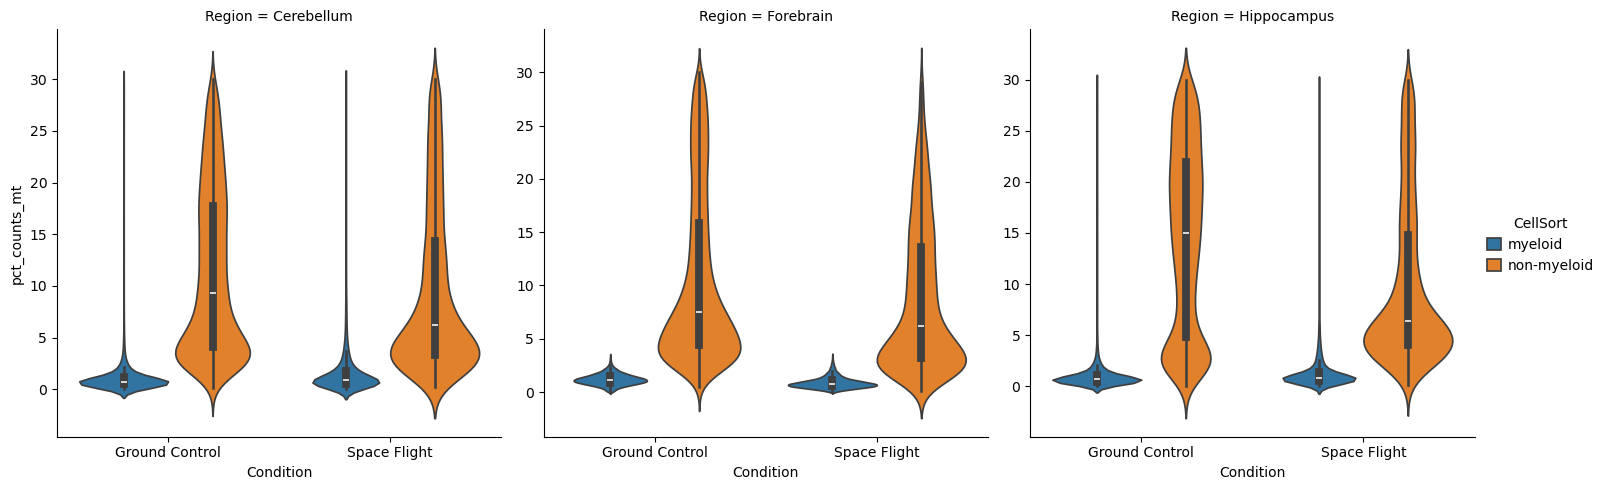

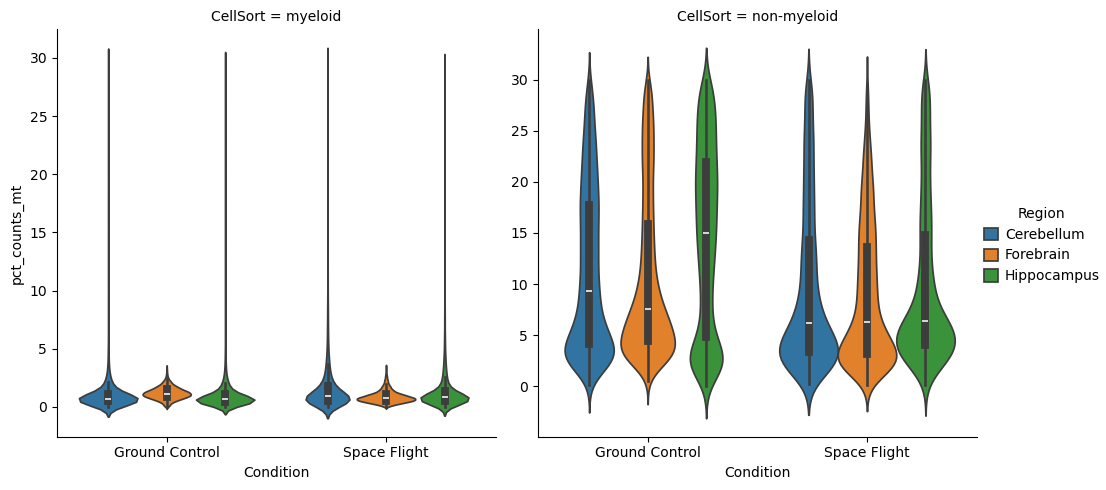

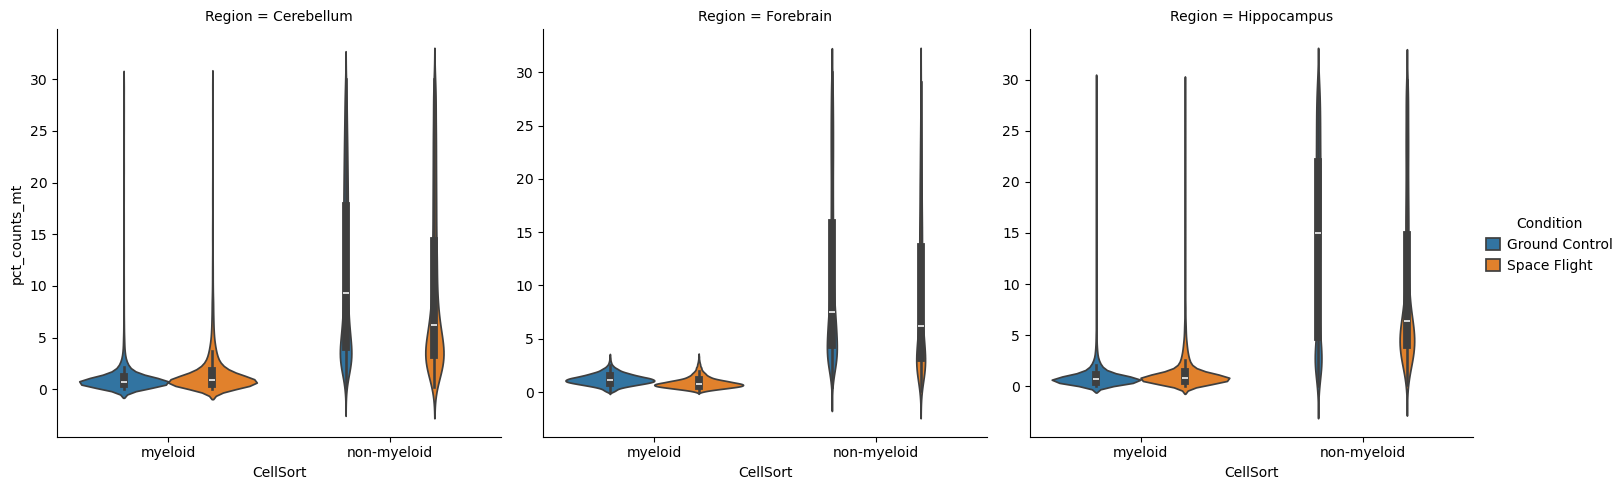

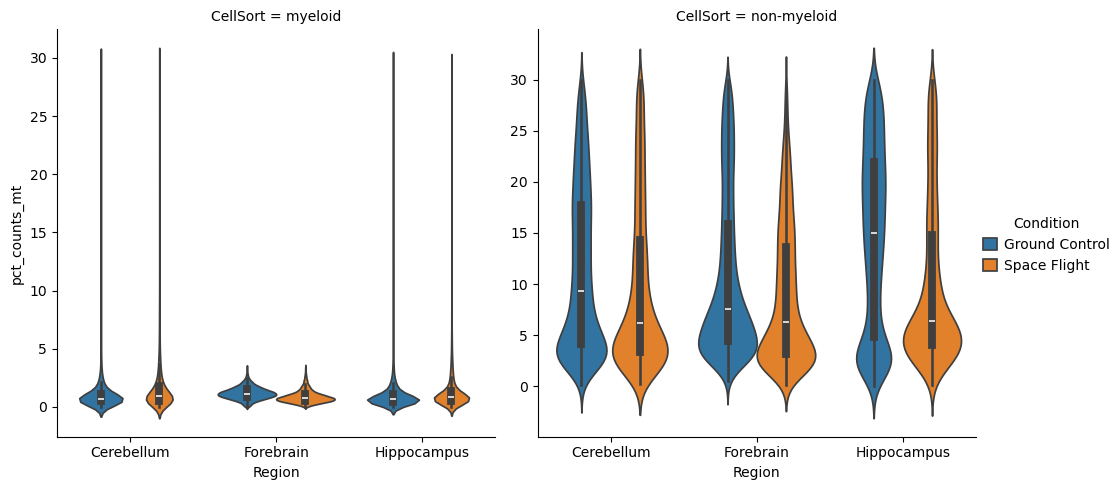

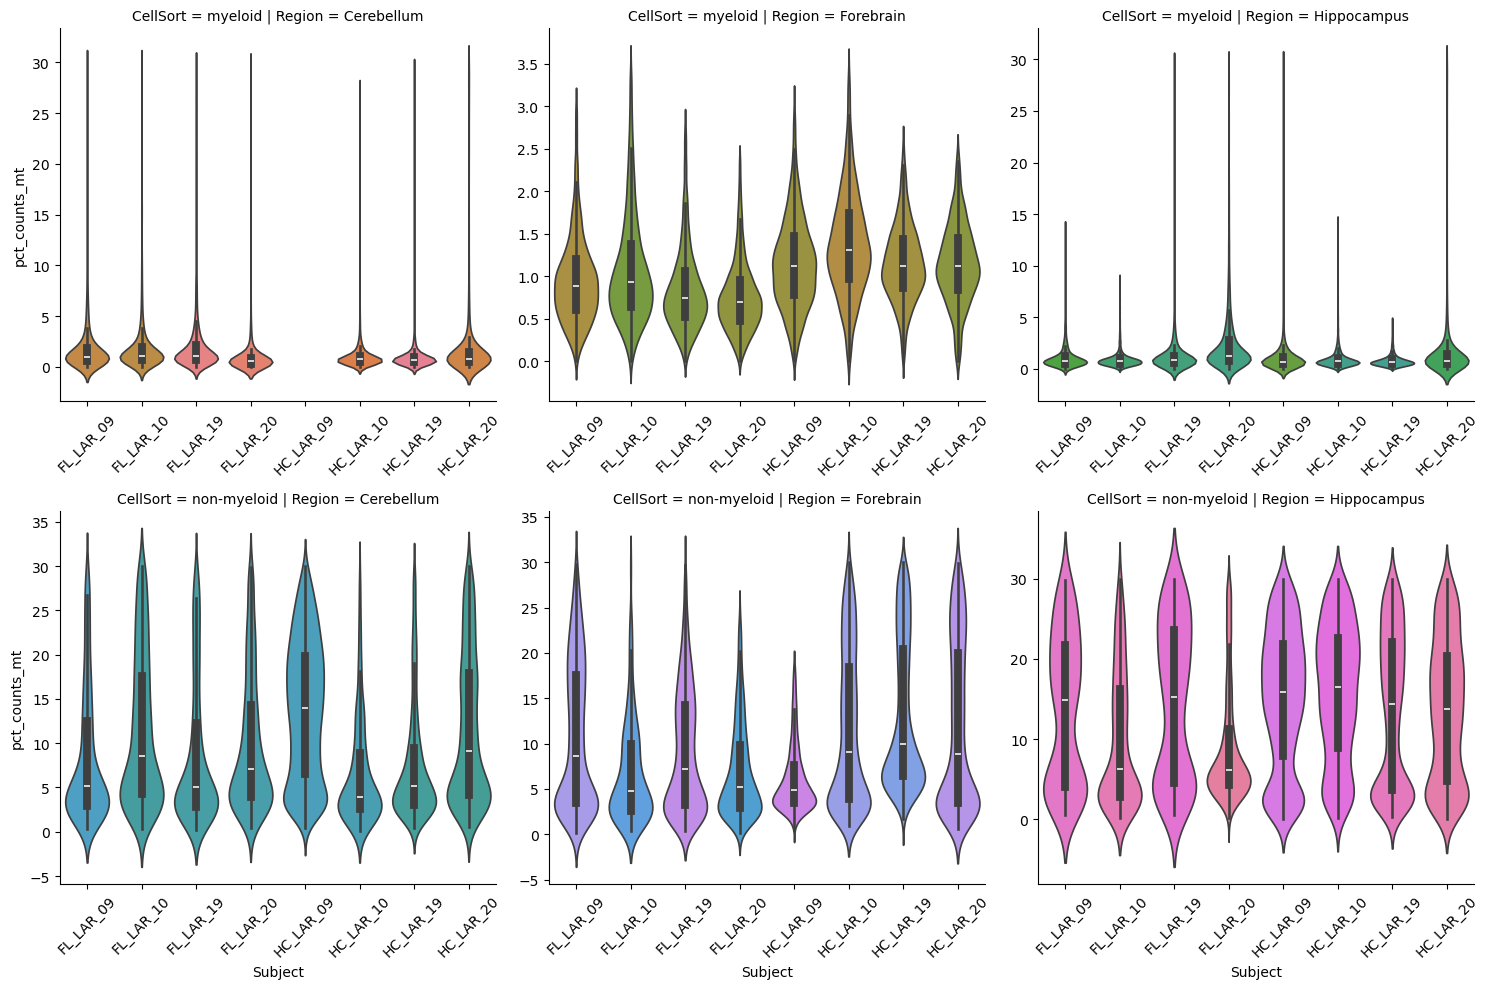

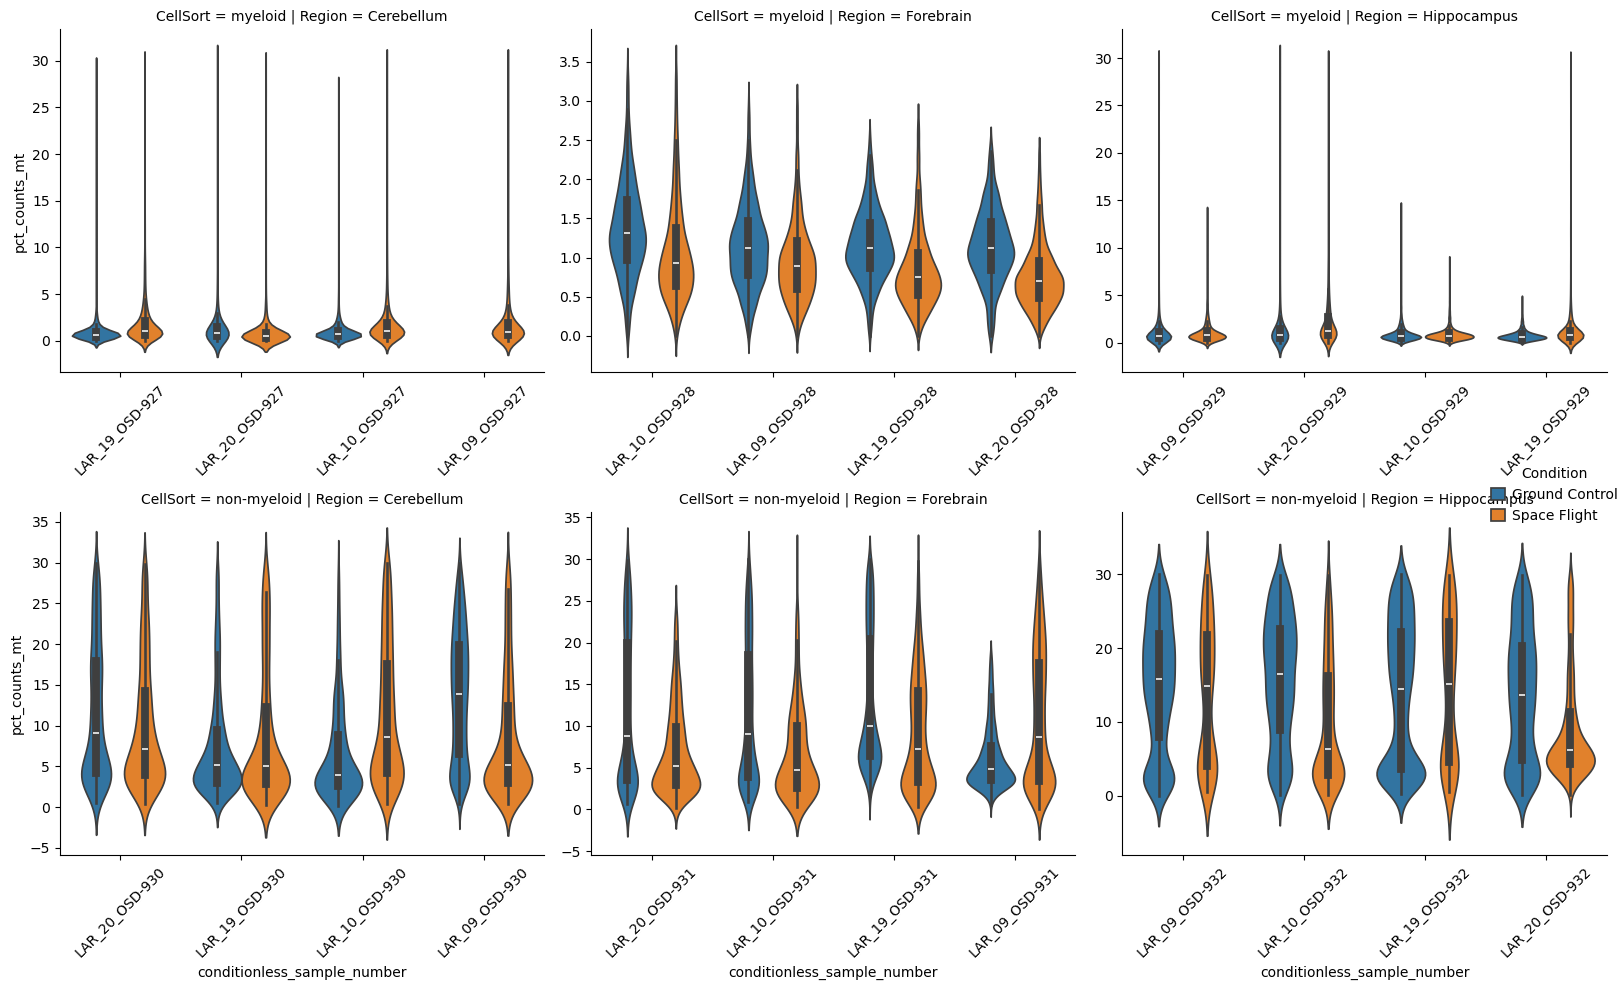

In [188]:
fig = sns.catplot(
        self.rna.obs[[col_sample, col_batch, col_region,
                      col_condition, "CellSort", "pct_counts_mt"]],
        x=col_condition, y="pct_counts_mt", hue="CellSort", col=col_region,
        kind="violin", sharey=False, sharex=False)

fig = sns.catplot(
        self.rna.obs[[col_sample, col_batch, col_region,
                      col_condition, "CellSort", "pct_counts_mt"]],
        x=col_condition, y="pct_counts_mt", col="CellSort", hue=col_region,
        kind="violin", sharey=False, sharex=False)

fig = sns.catplot(
        self.rna.obs[[col_sample, col_batch, col_region,
                      col_condition, "CellSort", "pct_counts_mt"]],
        x="CellSort", y="pct_counts_mt", hue=col_condition, col=col_region,
        kind="violin", sharey=False, sharex=False)

fig = sns.catplot(
        self.rna.obs[[col_sample, col_batch, col_region,
                      col_condition, "CellSort", "pct_counts_mt"]],
        col="CellSort", y="pct_counts_mt", hue=col_condition, x=col_region,
        kind="violin", sharey=False, sharex=False)

fig = sns.catplot(
        self.rna.obs[[col_sample, col_batch, col_region, col_subject,
                      col_condition, "CellSort", "pct_counts_mt"]],
        x=col_subject, y="pct_counts_mt",
        col=col_region, row="CellSort", hue=col_sample,
        kind="violin", sharey=False, legend=None, sharex=False)
for x in fig.axes.flatten():
    plt.sca(x)
    plt.xticks(rotation=45)
fig.fig.tight_layout()

pct_mts_all = self.rna.obs.join(self.rna.obs.groupby(
    col_sample).apply(lambda x: "_".join(x.name.split("_")[
        1:]), include_groups=False).to_frame(
            "conditionless_sample_number"), on=col_sample).loc[
                self.rna.obs.index]
pct_mts_all = pct_mts_all[[
    "conditionless_sample_number", col_sample, col_batch, col_region,
    col_condition, "CellSort", "pct_counts_mt"]]
fig = sns.catplot(
        pct_mts_all, x="conditionless_sample_number",
        y="pct_counts_mt", hue=col_condition, row="CellSort",
        col=col_region, kind="violin", sharey=False, sharex=False)
for x in fig.axes.flatten():
    plt.sca(x)
    plt.xticks(rotation=45)
fig.fig.tight_layout()

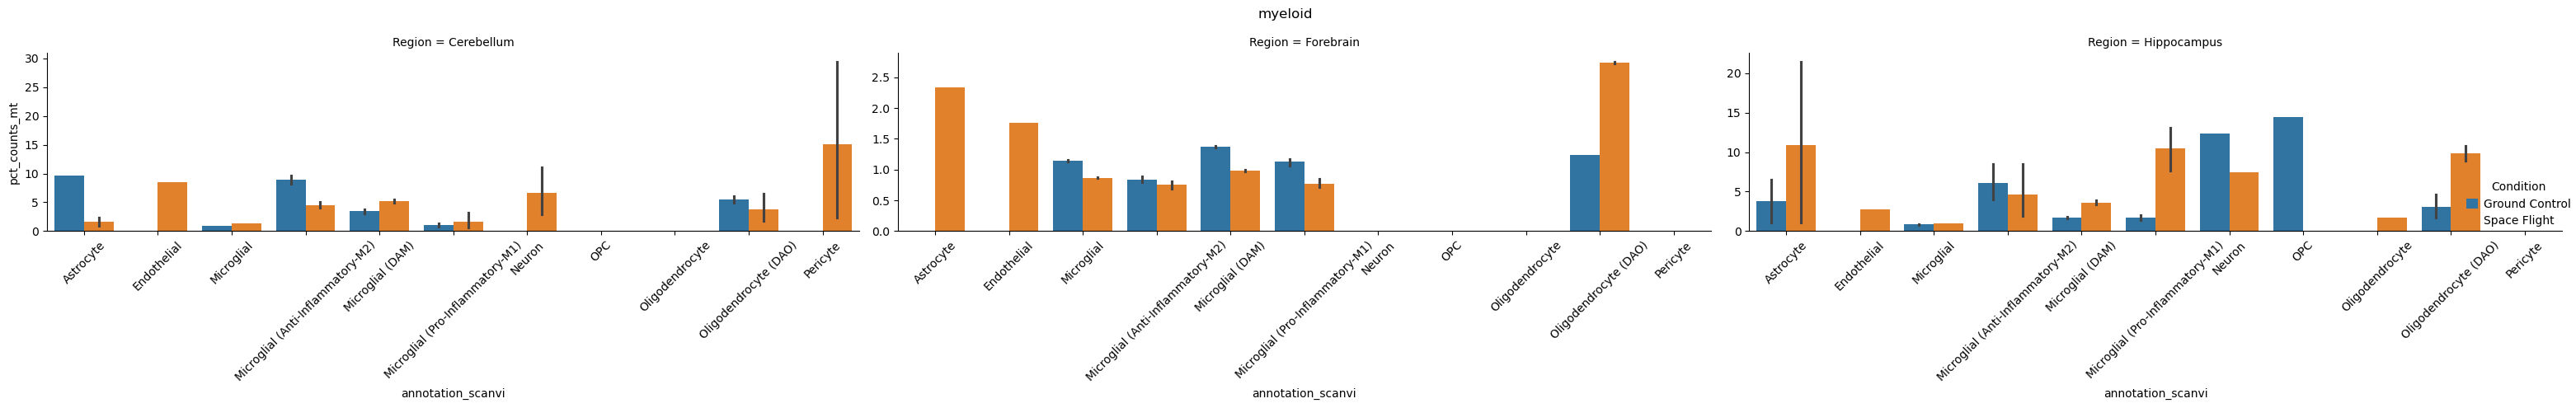

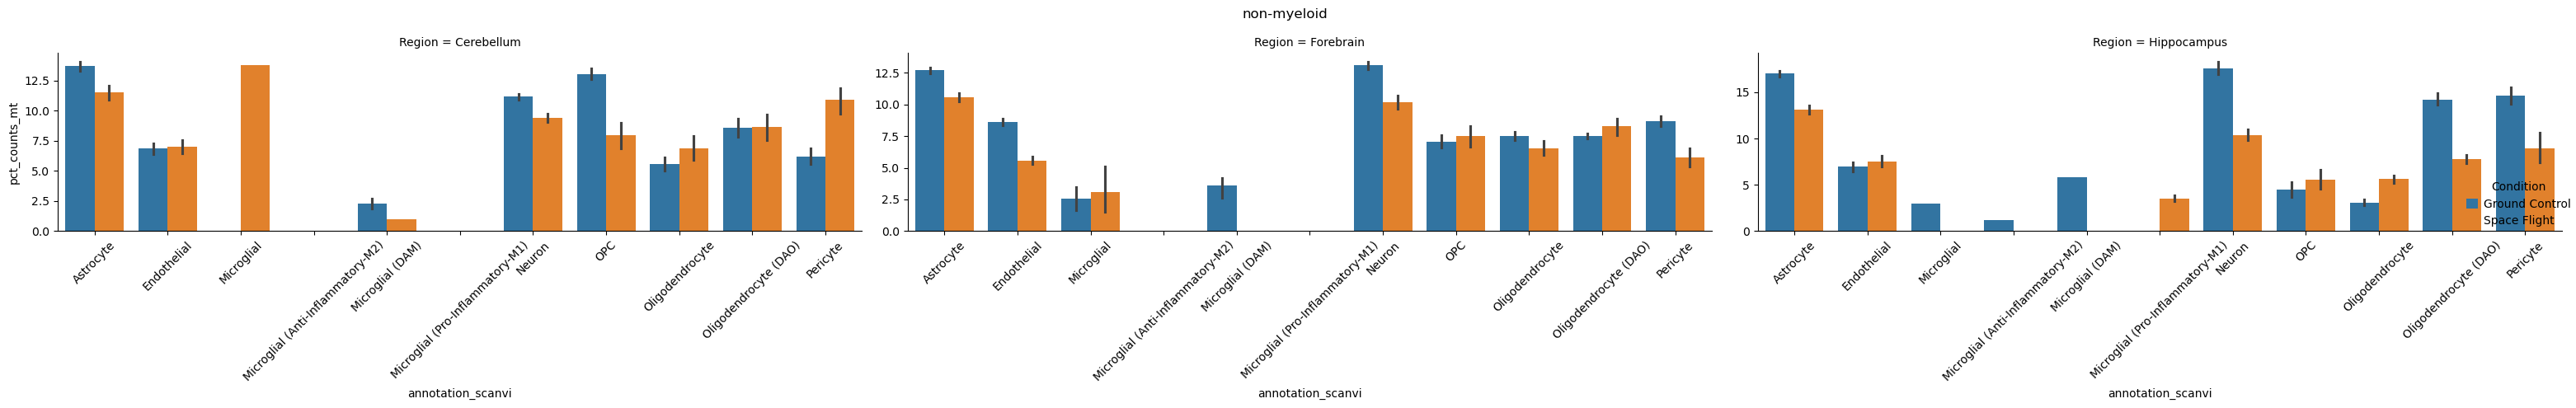

In [202]:
for t in self.rna.obs["CellSort"].unique():
        fig = sns.catplot(
                self.rna.obs[self.rna.obs["CellSort"] == t][[
                        col_sample, col_batch, col_region, col_celltype,
                        col_condition, "CellSort", "pct_counts_mt"]],
                x=col_celltype, y="pct_counts_mt",
                col=col_region, hue=col_condition,
                kind="bar", sharey=False, sharex=False, aspect=2)
        fig.fig.suptitle(t)
        for x in fig.axes.flatten():
                plt.sca(x)
                plt.xticks(rotation=45)
                fig.fig.tight_layout()

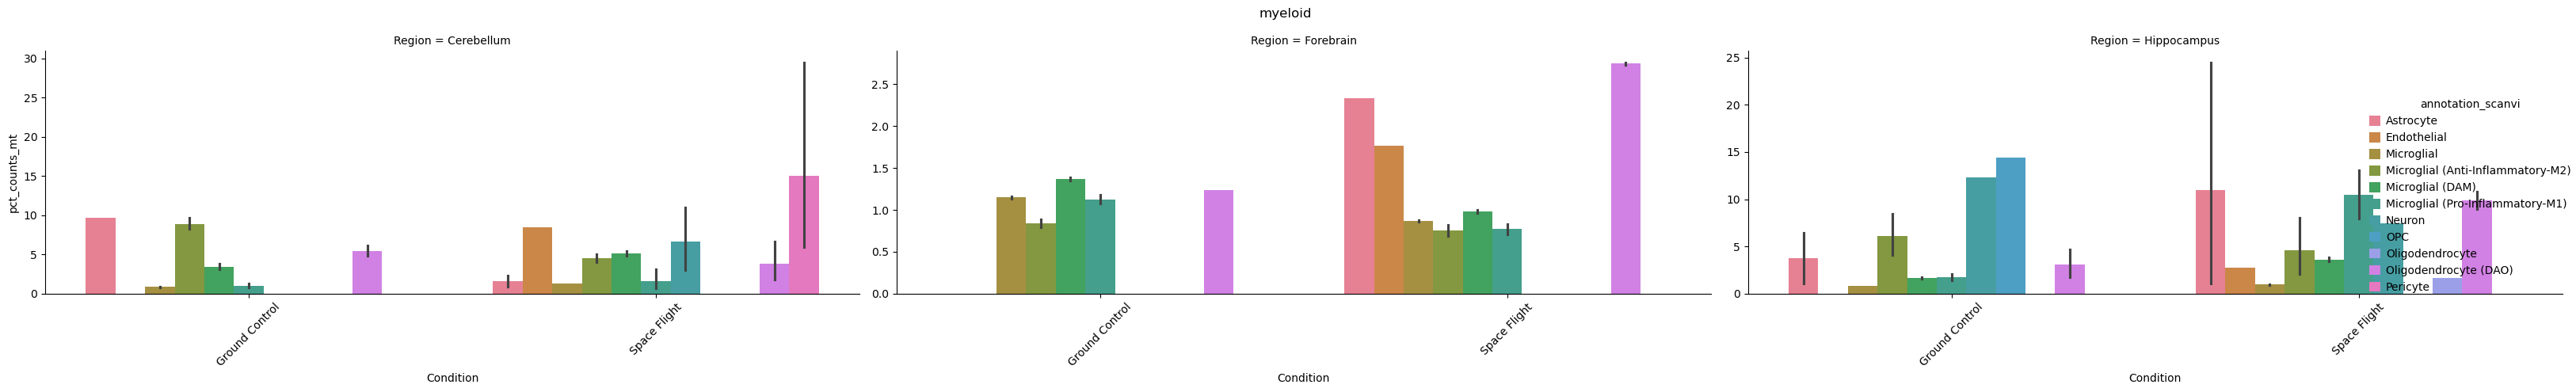

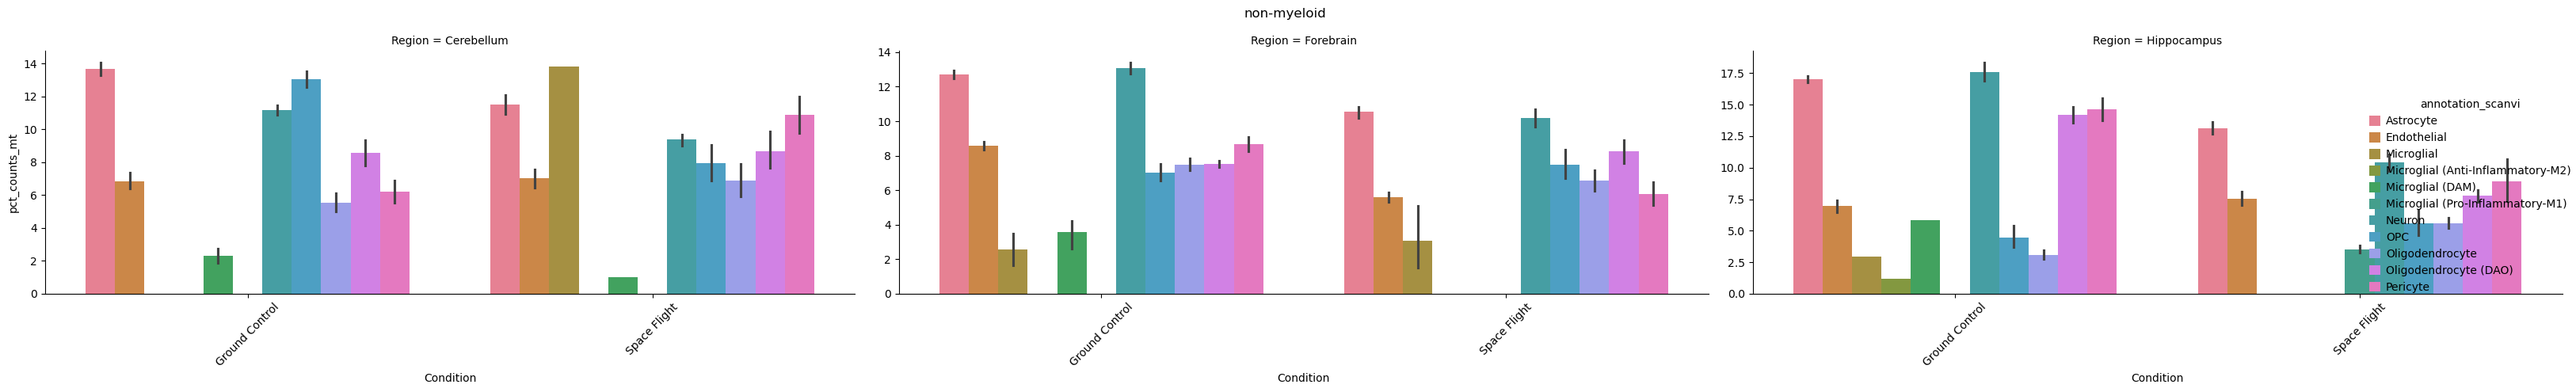

In [203]:
for t in self.rna.obs["CellSort"].unique():
        fig = sns.catplot(
                self.rna.obs[self.rna.obs["CellSort"] == t][[
                        col_sample, col_batch, col_region, col_celltype,
                        col_condition, "CellSort", "pct_counts_mt"]],
                hue=col_celltype, y="pct_counts_mt",
                col=col_region, x=col_condition,
                kind="bar", sharey=False, sharex=False, aspect=2)
        fig.fig.suptitle(t)
        for x in fig.axes.flatten():
                plt.sca(x)
                plt.xticks(rotation=45)
                fig.fig.tight_layout()

In [217]:
tmp = self.rna.obs.groupby("CellSort").value_counts(
    [col_celltype], normalize=True) * 100
tmp = tmp.to_frame("Percent")
tmp = tmp.join(tmp.groupby(col_celltype).apply(
    lambda x: "microglia" in x.name.lower()).to_frame("Myeloid"))
display(round(tmp, 3))
tmp.groupby(["CellSort", "Myeloid"]).sum()

Percent  Myeloid
CellSort    annotation_scanvi                                  
myeloid     Microglial                          76.829     True
            Microglial (DAM)                    20.233     True
            Microglial (Anti-Inflammatory-M2)    1.882     True
            Microglial (Pro-Inflammatory-M1)     0.997     True
            Astrocyte                            0.019    False
            Oligodendrocyte (DAO)                0.017    False
            Neuron                               0.014    False
            Endothelial                          0.003    False
            Pericyte                             0.003    False
            OPC                                  0.001    False
            Oligodendrocyte                      0.001    False
non-myeloid Astrocyte                           36.140    False
            Neuron                              24.362    False
            Oligodendrocyte (DAO)               13.102    False
            Endothelial                         11.889    False
            OPC                                  5.518    False
            Oligodendrocyte                      4.952    False
            Pericyte                             3.996    False
            Microglial                           0.017     True
            Microglial (DAM)                     0.017     True
            Microglial (Pro-Inflammatory-M1)     0.005     True
            Microglial (Anti-Inflammatory-M2)    0.002     True

Percent
CellSort    Myeloid           
myeloid     False     0.059202
            True     99.940798
non-myeloid False    99.959055
            True      0.040945

# Data Cleaning

## Collapse Cell Types (Optionally) & Plot Abundance

In [ ]:
%matplotlib inline

# Collapse Cell Types
if cts_collapsed is not None:
    self.rna.obs.loc[:, col_celltype + "_collapsed"] = self.rna.obs[
        col_celltype].map(cts_collapsed)
    col_celltype = col_celltype + "_collapsed"
    groupings = [i if i != col_celltype.split("_collapsed")[
        0] else col_celltype for i in groupings]

# Plot % Composition by Just Condition
grps = [i for i in groupings if i not in [col_celltype, col_subject]]
ct_comp_cond = (100 * self.rna.obs.groupby(col_condition).apply(
    lambda x: x.astype({col_subject: str}).groupby(col_subject).value_counts(
        [col_celltype], normalize=True), include_groups=False))
fig = sns.catplot(
    ct_comp_cond.to_frame("Composition (%)").reset_index(), x=col_celltype,
    y="Composition (%)", hue=col_condition, kind="box", margin_titles=True,
    errorbar="ci", units=col_subject,
    palette=palette[grps[0]] if grps[0] in palette else None)
fig.set_titles(row_template="{row_name}", col_template="{col_name}")
for a in fig.axes.flatten():
    a.tick_params(rotation=45)
display((100 * self.rna.obs.groupby(col_condition).value_counts([
    col_celltype], normalize=True)).unstack(col_condition).round(2))

# Plot % Composition
ct_comp = (100 * self.rna.obs.groupby(grps).apply(
    lambda x: x.astype({col_subject: str}).groupby(col_subject).value_counts(
        [col_celltype], normalize=True), include_groups=False))
fig = sns.catplot(
    ct_comp.to_frame("Composition (%)").reset_index(), x=col_celltype,
    y="Composition (%)", hue=grps[0], col=grps[1] if len(grps) > 1 else None,
    row=grps[2] if len(grps) > 2 else None, height=5, aspect=2,
    kind="bar", margin_titles=True, errorbar="ci", units=col_subject,
    palette=palette[grps[0]] if grps[0] in palette else None)
fig.set_titles(row_template="{row_name}", col_template="{col_name}")
for a in fig.axes.flatten():
    a.tick_params(rotation=45)

# Print Cell Type % by Groupings
(100 * self.rna.obs.groupby(grps).value_counts([
        col_celltype], normalize=True)).unstack(grps[0]).round(2)

NameError: name 'self' is not defined

## Senescence Pathways

Also used the following code to look at overlap of Senmayo genes with Hallmark and Progeny pathways.

```
# Senescence Markers
mks_snc = pd.read_csv("pathways_senescence.csv", index_col=0)[
    "target"].dropna().apply(lambda x: x.strip().split(","))
mkdf_snc = mks_snc.explode().to_frame("target").reset_index()

# Online Pathway Databases
resource = pd.concat({
    "Hallmark": dc.op.hallmark(organism=species.lower()),
    "Progeny": dc.op.progeny(organism=species.lower())}).reset_index(
        0, drop=True)
if "weight" in resource:
    resource["weight"] = resource["weight"].fillna(1)

# SnC Gene Pathways
resource_snc = {g: list(resource[resource["target"] == g][
    "source"].unique()) + ["Senmayo"] if g in resource["target"].tolist(
        ) else ["Senmayo"] for g in mkdf[mkdf["source"] == "Senmayo"][
            "target"].unique()}
for i in ["Wnt2"]:  # Add Custom
    resource_snc[i] = resource_snc[i] + ["Down_Triggers_SnC"]
resource_snc = pd.Series(resource_snc).rename_axis("target").to_frame(
    "source").explode("source").reset_index()

# Join Weights
resource_snc = resource_snc.set_index(["source", "target"]).join(
    resource.set_index(["source", "target"])[["weight"]]).reset_index()
resource_snc.loc[resource_snc["source"] == "Senmayo", "weight"] = 1
resource_snc.loc[resource_snc["source"] == "Down_Triggers_SnC", "weight"] = 1

# Collapse Similar Pathways
tmp = resource_snc.copy()
resource_snc["source"] = resource_snc["source"].replace({
    x: x.upper() for x in resource_snc["source"].unique() if x.upper(
        ) in resource_snc["source"].unique() and x != x.upper()})
resource_snc["source"] = resource_snc["source"].replace({
    x: f"{x.upper()}_PATHWAY" for x in resource_snc["source"].unique() if (
        f"{x.upper()}_PATHWAY" in resource_snc["source"].unique())})
resource_snc["source"] = resource_snc["source"].replace(
    "TGFb", "TGF_BETA_SIGNALING")
resource_snc["source"] = resource_snc["source"].replace(
    "Trail", "APOPTOSIS")

# Weight = -1 for Downregulated (Any Negative Weight), 1 for Upregulated
resource_snc["weight"] = resource_snc["weight"].apply(
    lambda x: -1 if x < 0 else 1)

# View Changes
print(tmp.compare(resource_snc).value_counts())
print(tmp[["weight"]].compare(resource_snc[["weight"]]).value_counts())

# Drop If Too Few Genes in Pathway
resource_snc = resource_snc.set_index("source").join(resource_snc.groupby(
    "source").apply(lambda x: len(x["target"].unique()),
                    include_groups=False).to_frame("n_genes")).reset_index()
resource_snc = resource_snc.set_index("source").sort_index().reset_index()
resource_snc_drop = resource_snc["n_genes"] < 3
print("\n\n\nDropping rows with too few genes in pathway: "
      f"{resource_snc[resource_snc_drop].source.unique()}...")
resource_snc = resource_snc[~resource_snc_drop].drop("n_genes", axis=1)
display(resource_snc["source"].unique())
display(resource_snc)

# List Format
# resource_snc_lists = resource_snc[resource_snc.source.isin(tmp_ps)].groupby(
#     "target").apply(lambda x: [i for i in x["source"].unique().tolist() if (
#         i != "Senmayo")], include_groups=False)
# resource_snc_lists = resource_snc[resource_snc.source.isin(tmp_ps)].groupby(
#     "source").apply(lambda x: ", ".join([i for i in x["target"].unique(
#         ).tolist() if i != "Senmayo"]), include_groups=False)
# for i in resource_snc_lists.index:
#     print(f"{i}: {resource_snc_lists[i]}")
tmp_ps = [
    ""
    # Senescence Inducers
    "Senmayo", "APOPTOSIS", "P53_PATHWAY",
    "TGF_BETA_SIGNALING", "TNFA_SIGNALING_VIA_NFKB", "TNFa", "NFkB", "MAPK",
    "INTERFERON_GAMMA_RESPONSE", "INTERFERON_ALPHA_RESPONSE",
    # "PI3K", "KRAS_SIGNALING_UP", "KRAS_SIGNALING_DN", "WNT" # complex?
    "JAK-STAT", "IL6_JAK_STAT3_SIGNALING", "IL2_STAT5_SIGNALING",
    # Cell Responses/Stress/SASP
    "INFLAMMATORY_RESPONSE", "VEGF", "UNFOLDED_PROTEIN_RESPONSE",
    "UV_RESPONSE_UP", "HYPOXIA",
    "CHOLESTEROL_HOMEOSTASIS", "APICAL_JUNCTION",
    # "EPITHELIAL_MESENCHYMAL_TRANSITION"
]
# print("\n".join([x + "," + '"' + ",".join(resource_snc[resource_snc[
#     "source"] == x].target.unique()) + '"' for x in tmp_ps]))

# print(resource_snc["target"].unique())
# {x: [i for i in resource_snc["target"].unique() if x in i] for x in [
#     "Mmp", "Il", "Ccl", "Cxcl", "Igfbp", "Wnt", "Serpin"]}

# vcs = resource_snc[resource_snc.source.isin(tmp_ps)].groupby(
#     "target").apply(lambda x: [i for i in x["source"].unique().tolist() if (
#         i != "Senmayo")], include_groups=False)
# # .apply(lambda x: pd.Series(x, index=x)).replace(np.nan, "").value_counts()
# vcs.apply(lambda x: x if len(x) == 3 else np.nan).dropna()

# resource_snc[resource_snc["target"] == "Bcl3"].source.unique()

# np.unique(resource_snc[resource_snc["source"].isin([
#     "TNFA_SIGNALING_VIA_NFKBTN", "TNFa", "NFkB"])]["target"])
# np.unique(resource_snc[resource_snc["source"].isin(["P53_PATHWAY"])].target)

# resource_snc[resource_snc["target"].isin(np.unique(resource_snc[
#     resource_snc["source"].isin(["P53_PATHWAY"])].target))][
#         "source"].unique()

# pd.get_dummies(resource_snc[resource_snc["source"].isin(
#     tmp_ps)].set_index("source")["target"])

# path_snc_df
```



***Plotting group Microglial (0.0%)...


... storing 'annotation_scanvi_collapsed' as categorical




***Plotting group Astrocyte (14.3%)...


... storing 'annotation_scanvi_collapsed' as categorical




***Plotting group Oligodendrocyte (28.6%)...


...



***Plotting group Endothelial (71.4%)...


... storing 'annotation_scanvi_collapsed' as categorical




***Plotting group OPC (85.7%)...


... storing 'annotation_scanvi_collapsed' as categorical


reference  weight
source               target                                                                                
Senmayo              Acvr1b     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ang        https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Angpt1     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Angptl4    https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Areg       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Axl        https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Bex3       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Bmp2       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Bmp6       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     C3         https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl1       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl2       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl20      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl24      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl26      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl3       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl4       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl5       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl7       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ccl8       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cd55       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cd9        https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Csf1       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Csf2       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Csf2rb     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ctnnb1     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Ctsb       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl1      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl10     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl12     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl16     https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl2      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcl3      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Cxcr2      https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Dkk1       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO     1.0
                     Edn1       https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN

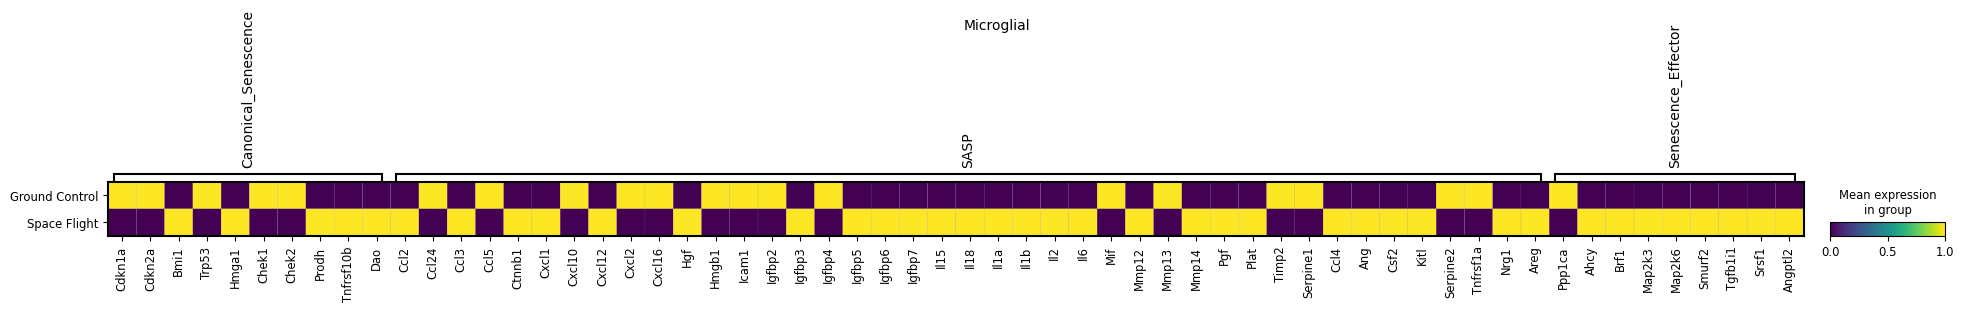

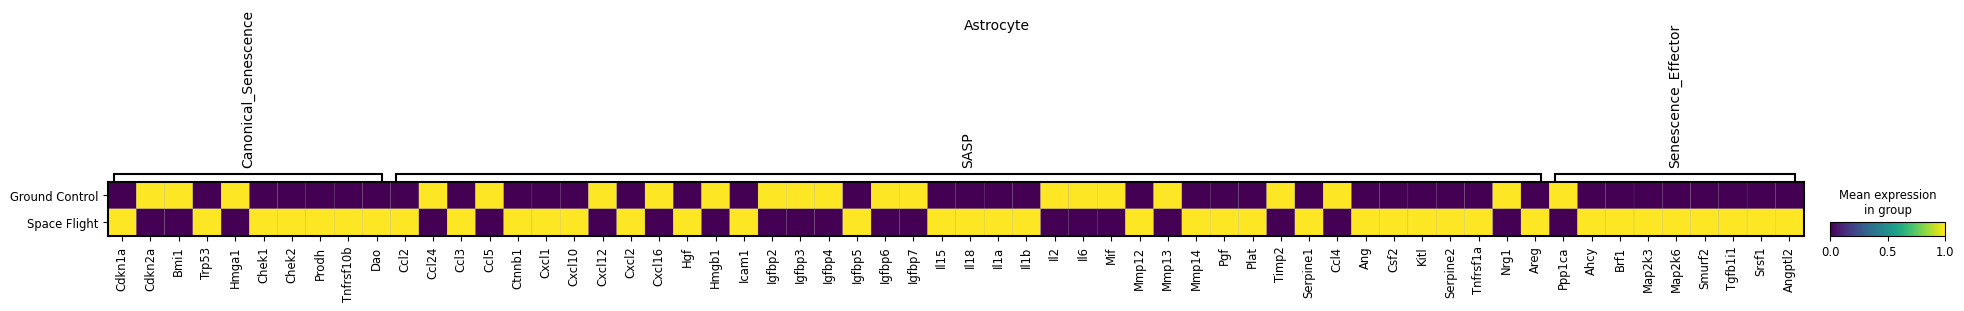

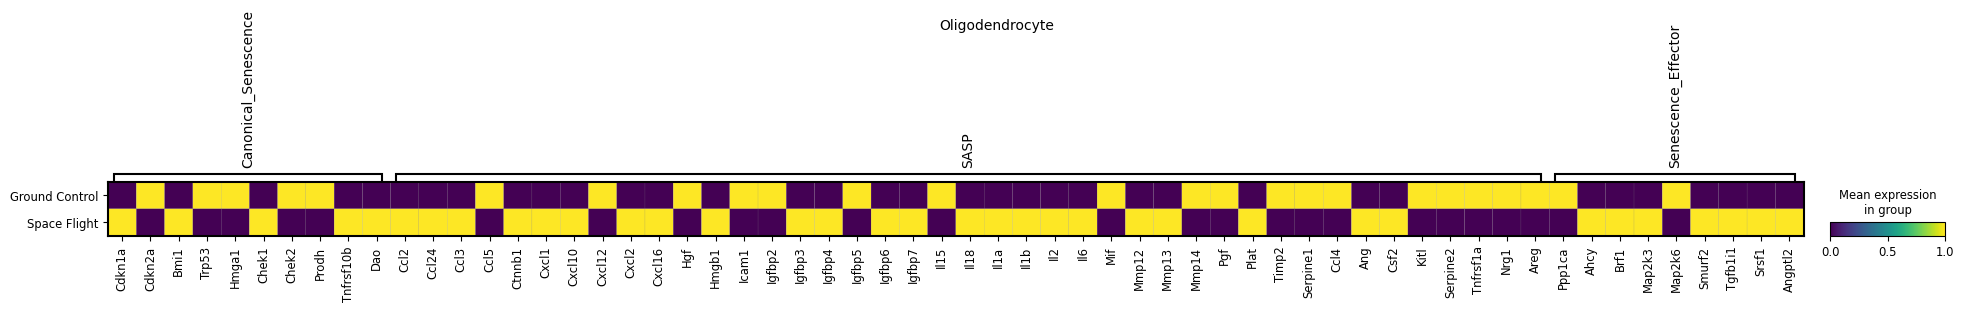

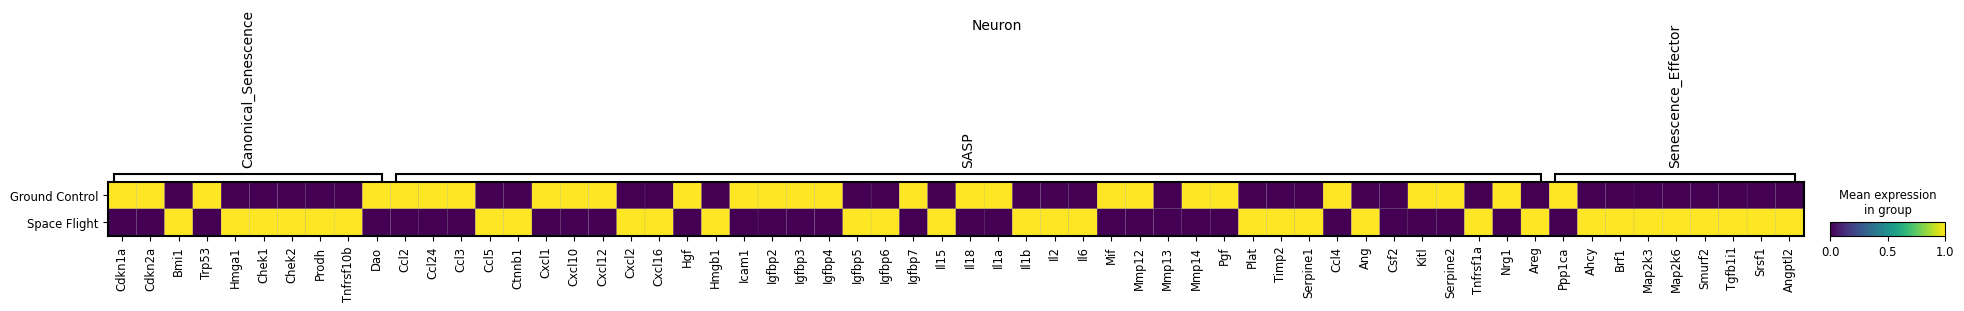

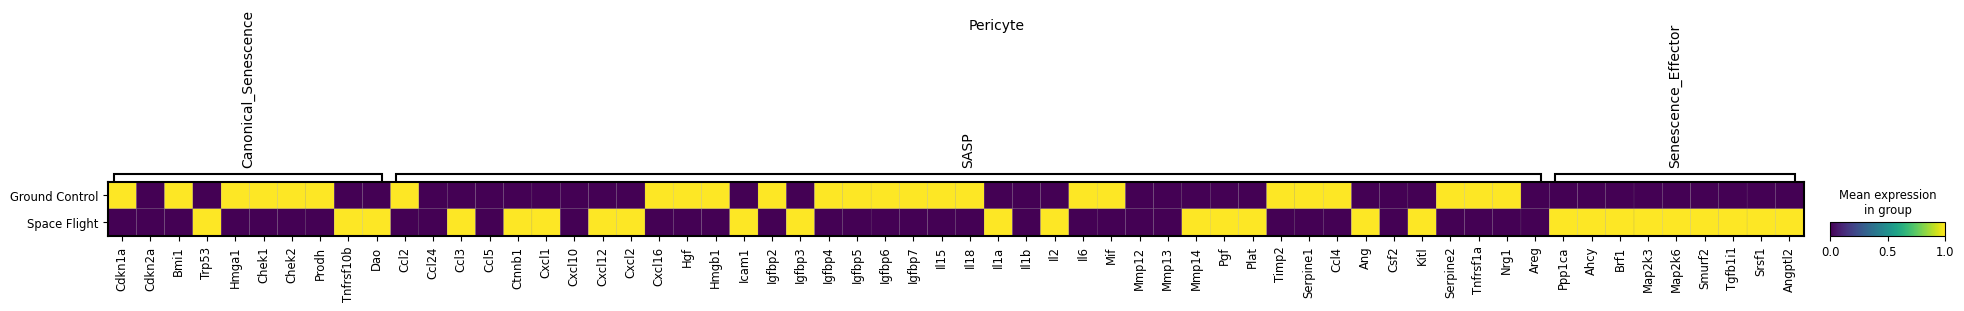

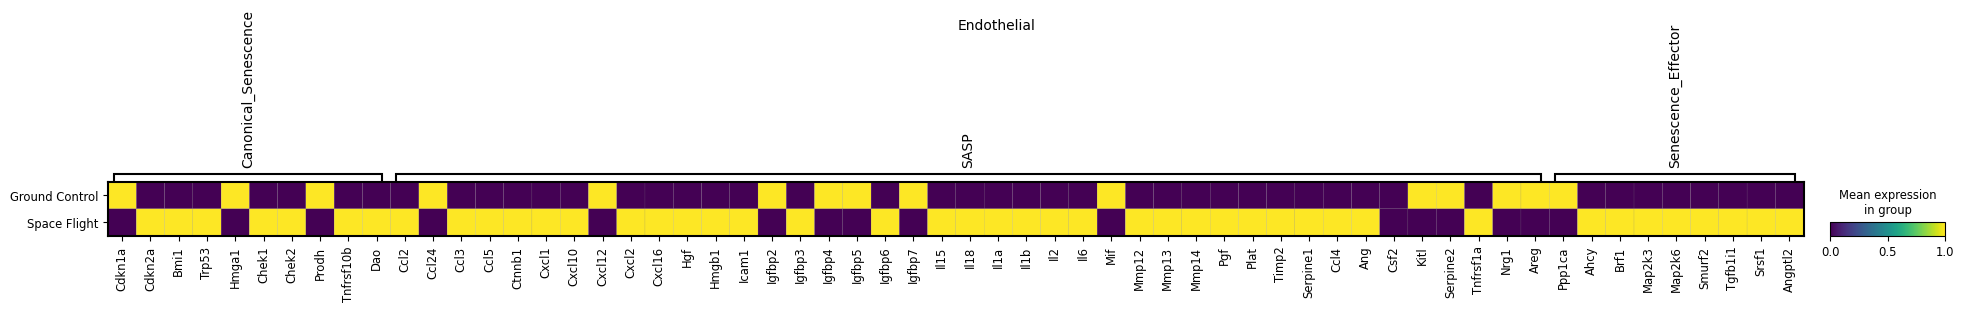

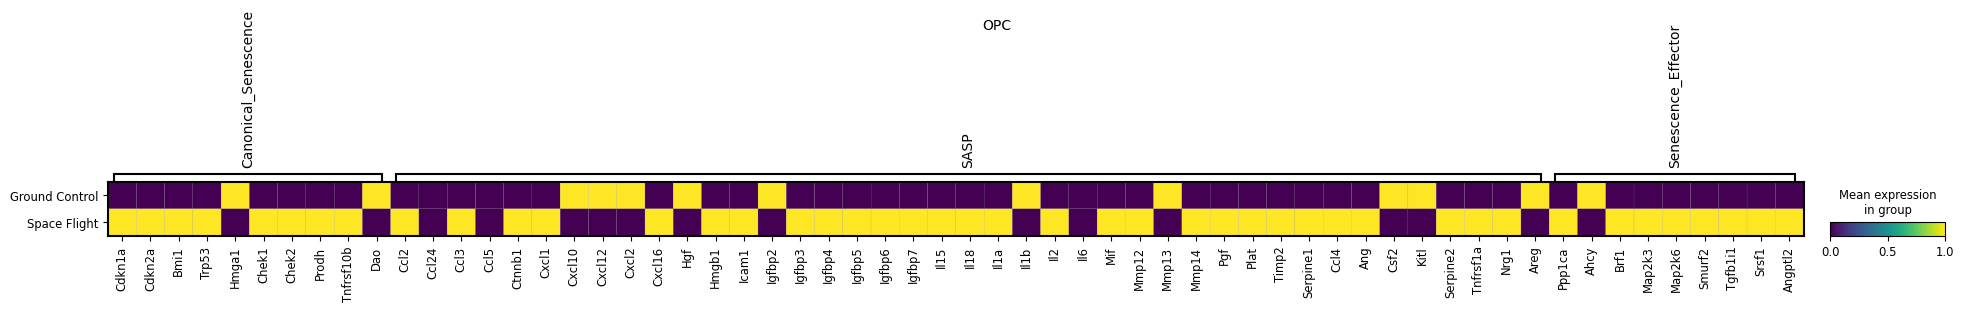

In [3]:
path_snc_df = pd.read_csv("pathways_senescence.csv", index_col=0).apply(
    lambda x: x.apply(lambda y: y.split(",") if "," in str(y) else y))
if "weight" not in path_snc_df:
    path_snc_df["weight"] = 1
path_snc_df["weight"] = path_snc_df["weight"].fillna(1)
weights = path_snc_df.apply(lambda x: dict(zip(x["target"], [
    x["weight"]] * len(x["target"]) if not isinstance(x["weight"], (
        list, np.ndarray, tuple)) else x["weight"])), axis=1
)  # if all same weight, make list of weights for each gene
weights = pd.DataFrame(dict(weights)).stack().reorder_levels([
    1, 0]).sort_index().rename_axis(["source", "target"]).to_frame("weight")
path_snc_df = path_snc_df.drop("weight", axis=1).explode("target").set_index(
    "target", append=True).join(weights).reset_index().drop_duplicates(
        subset=["source", "target"])
path_snc_dict = dict(path_snc_df.groupby("source").apply(
    lambda x: list(x["target"]), include_groups=False))
genes = {k: path_snc_dict[k] for k in path_snc_dict if k != "Senmayo"}
_ = self.plot(
    genes=genes, kind="matrix", standard_scale="var", layer="scaled",
    col_celltype=col_condition, by_group=col_celltype)
# self.plot(genes=genes["SASP"], col_celltype=col_condition,
#           figsize=(40, 40), kind="violin")
# self.plot(genes=genes["SASP"], col_celltype=col_condition,
#           by_group=col_celltype, figsize=(40, 40), kind="violin")
path_snc_df.set_index(["source", "target"])

## Senescence?

To check if about 1% came out as senescent:

```
100 * self.rna[senescence_control_subset].obs[[
    col_celltype, "Senescent"]].groupby(col_celltype).mean()
```

or if threshold not cell type-specific

```
100 * self.rna[senescence_control_subset].obs[[
    col_celltype, "Senescent"]].mean()
```

SnC Microglial             23 Samples
Non-SnC Microglial         35 Samples
Non-SnC Astrocyte          34 Samples
Non-SnC Oligodendrocyte    36 Samples
Non-SnC Neuron             29 Samples
Non-SnC Pericyte           26 Samples
SnC Oligodendrocyte        22 Samples
Non-SnC Endothelial        27 Samples
SnC Astrocyte              24 Samples
Non-SnC OPC                25 Samples
SnC OPC                    21 Samples
SnC Pericyte               17 Samples
SnC Neuron                 22 Samples
SnC Endothelial            23 Samples
dtype: object
                                 Senescent             
Condition                   Ground Control Space Flight
annotation_scanvi_collapsed                            
Astrocyte                              4.7          3.8
Endothelial                            6.3          5.9
Microglial                             5.0          2.9
Neuron                                 5.1          2.9
OPC                                    6.4         15.7
Oligod

Senescent             
Condition                            Ground Control Space Flight
Age      annotation_scanvi_collapsed                            
3 Months Astrocyte                              5.0          4.0
         Endothelial                            5.1          8.6
         Microglial                             5.0          2.8
         Neuron                                 5.0          2.9
         OPC                                    5.0         24.2
         Oligodendrocyte                        5.0          4.6
         Pericyte                               5.0          1.9
8 Months Astrocyte                              4.5          3.7
         Endothelial                            7.5          3.8
         Microglial                             4.9          3.0
         Neuron                                 5.1          3.0
         OPC                                    9.4         12.8
         Oligodendrocyte                        3.6          3.6
         Pericyte                               2.8          9.9

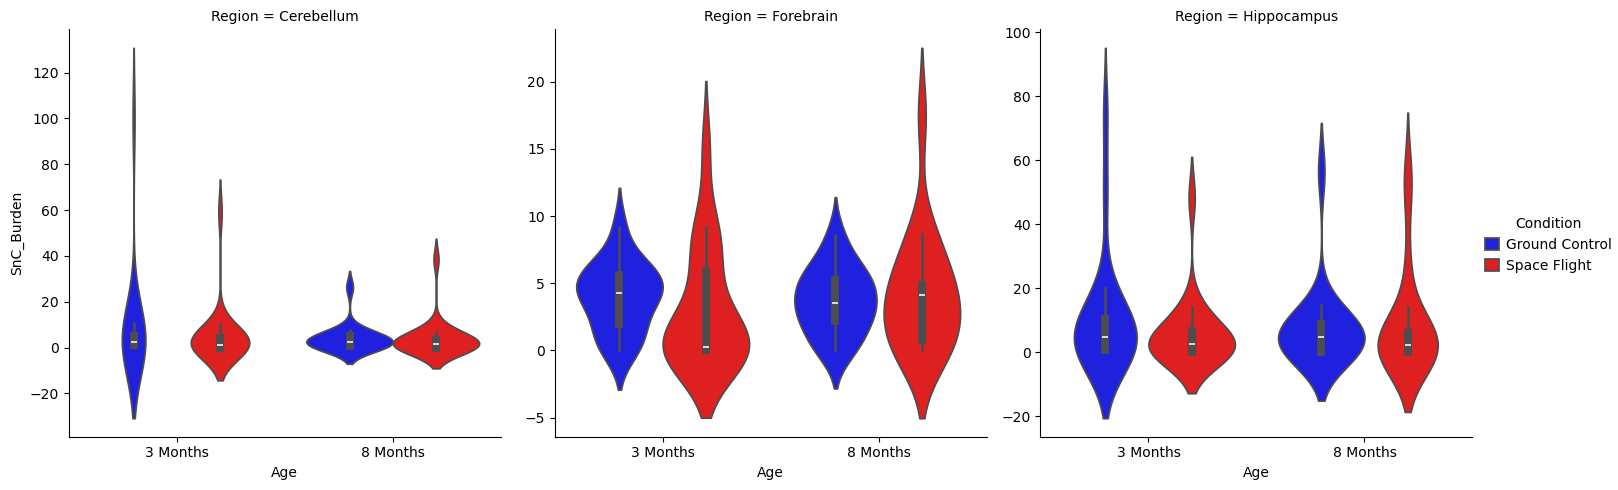

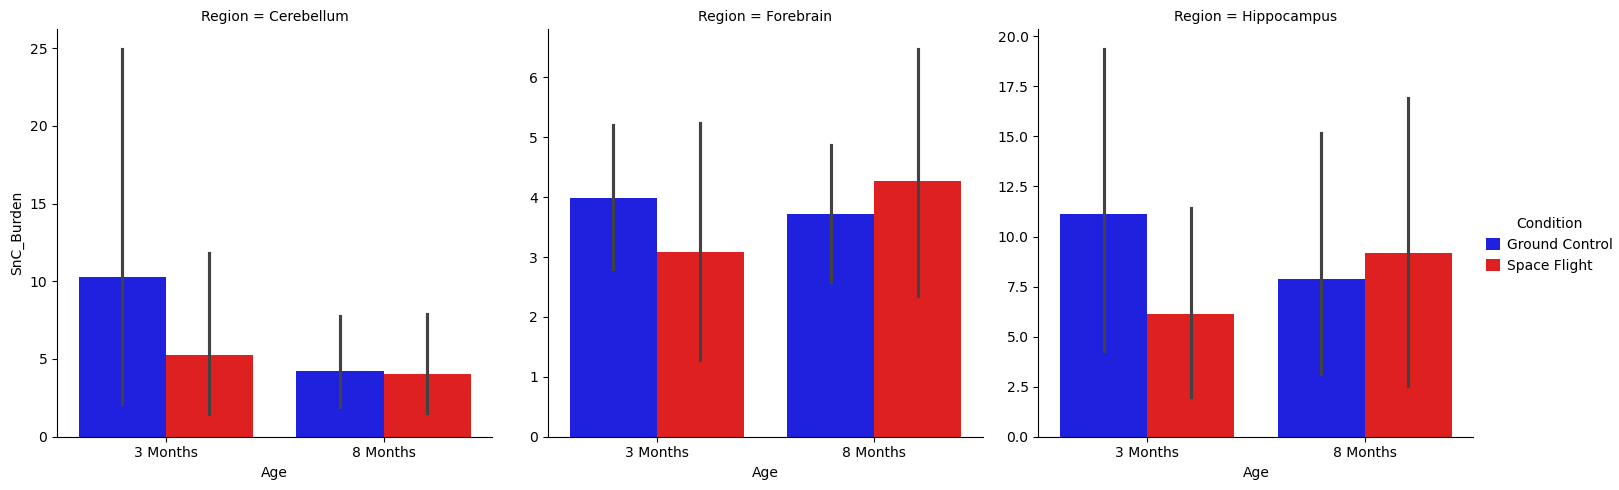

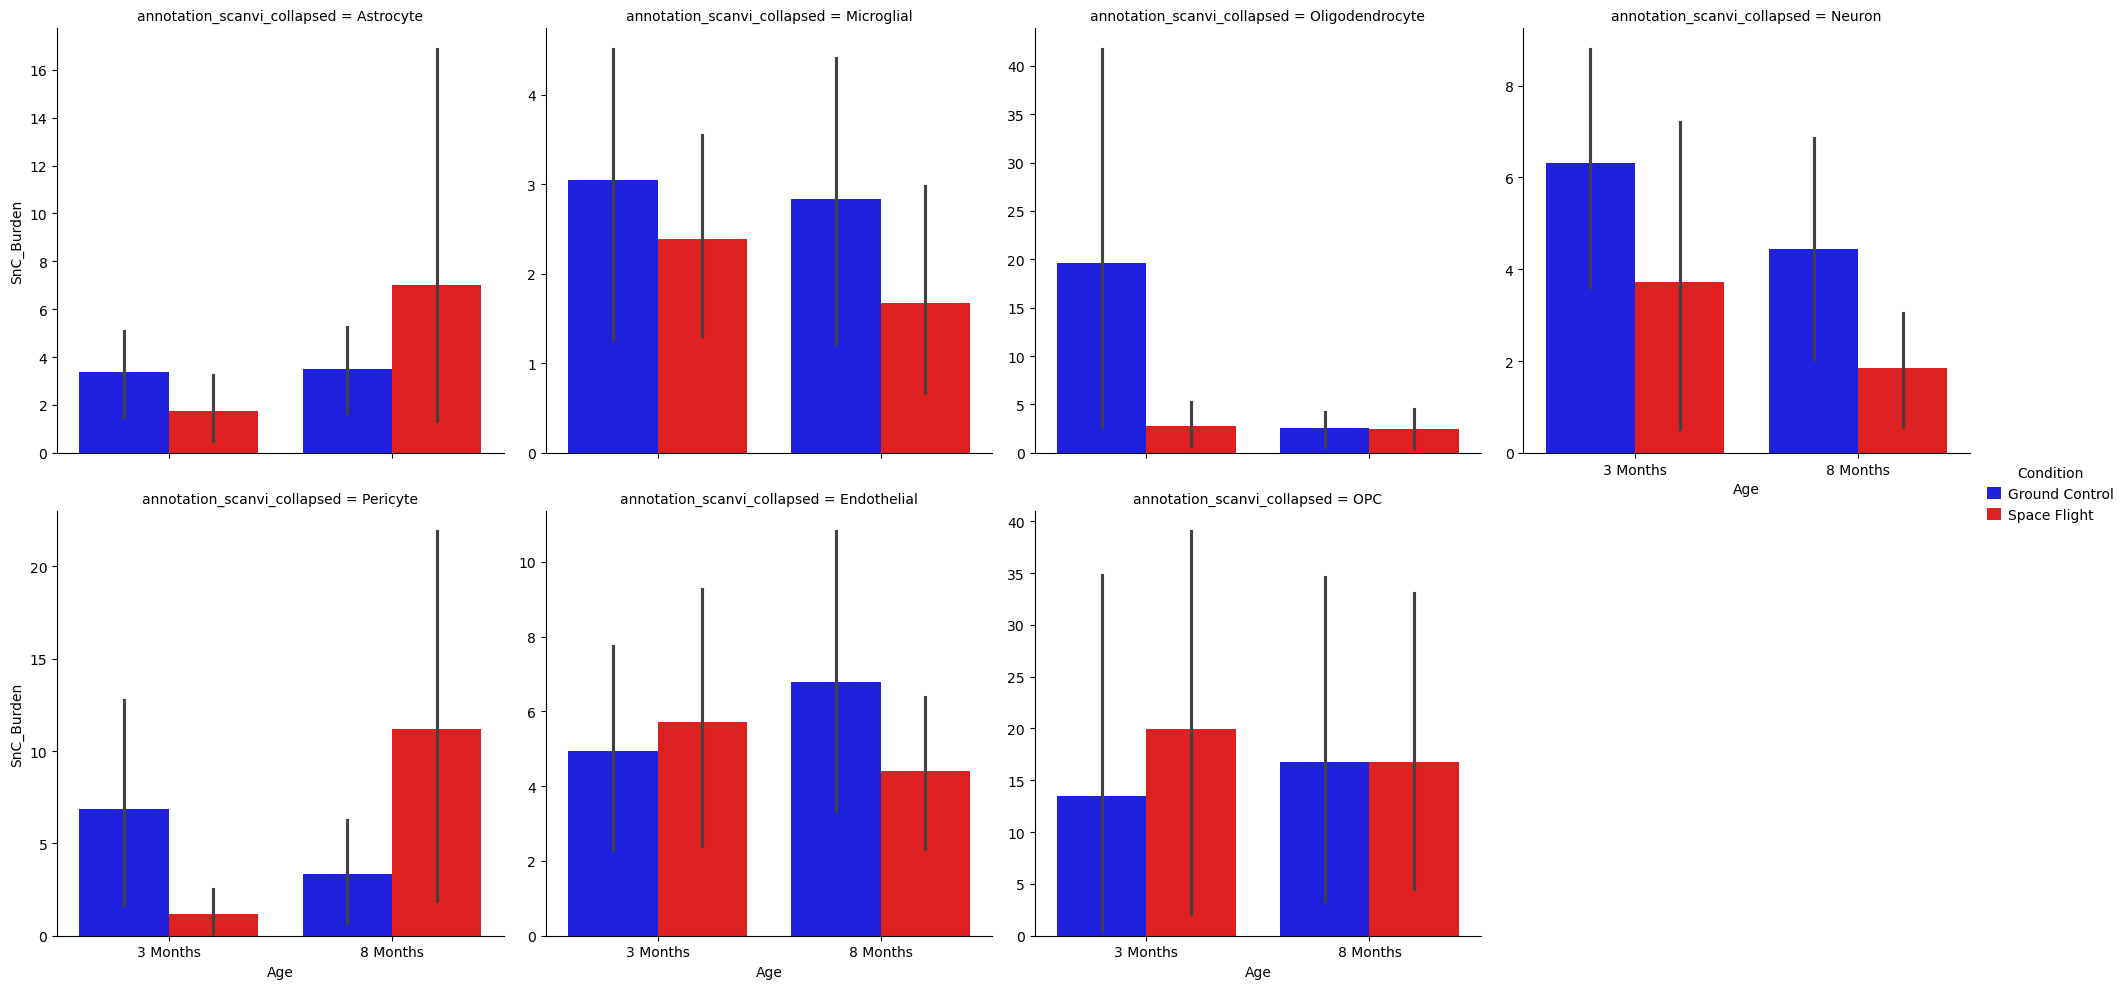

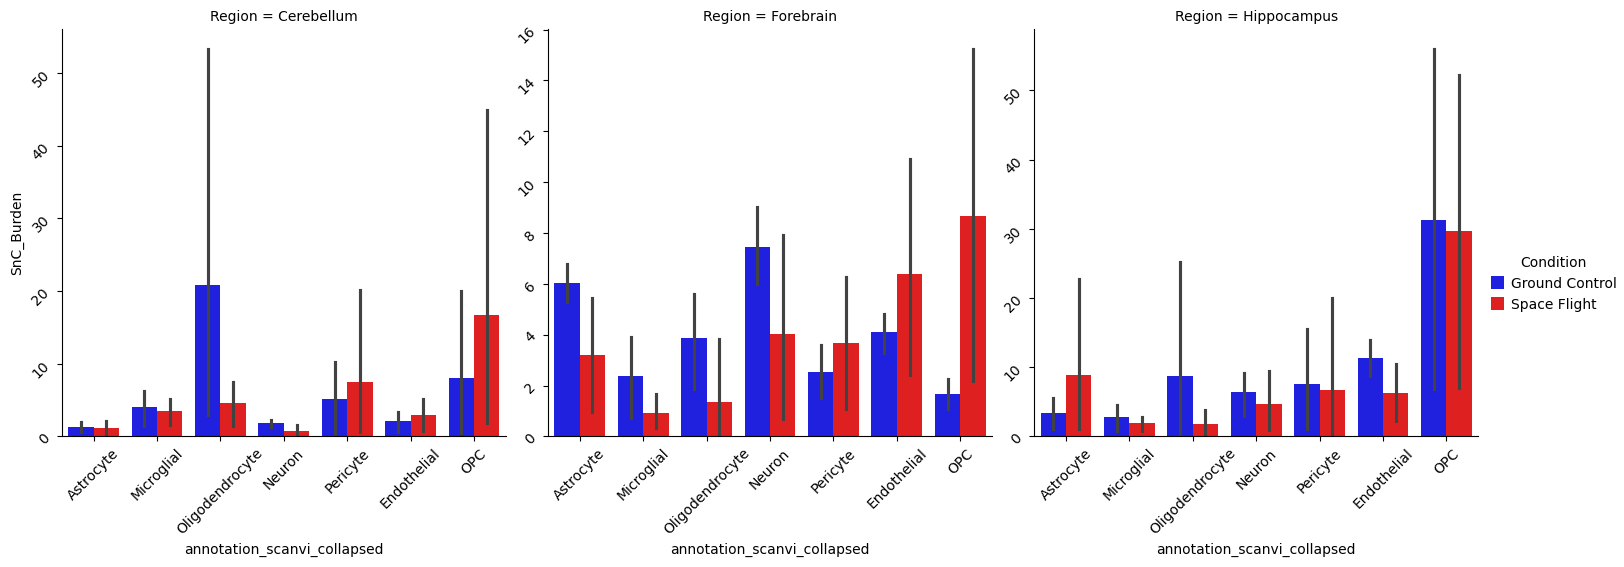

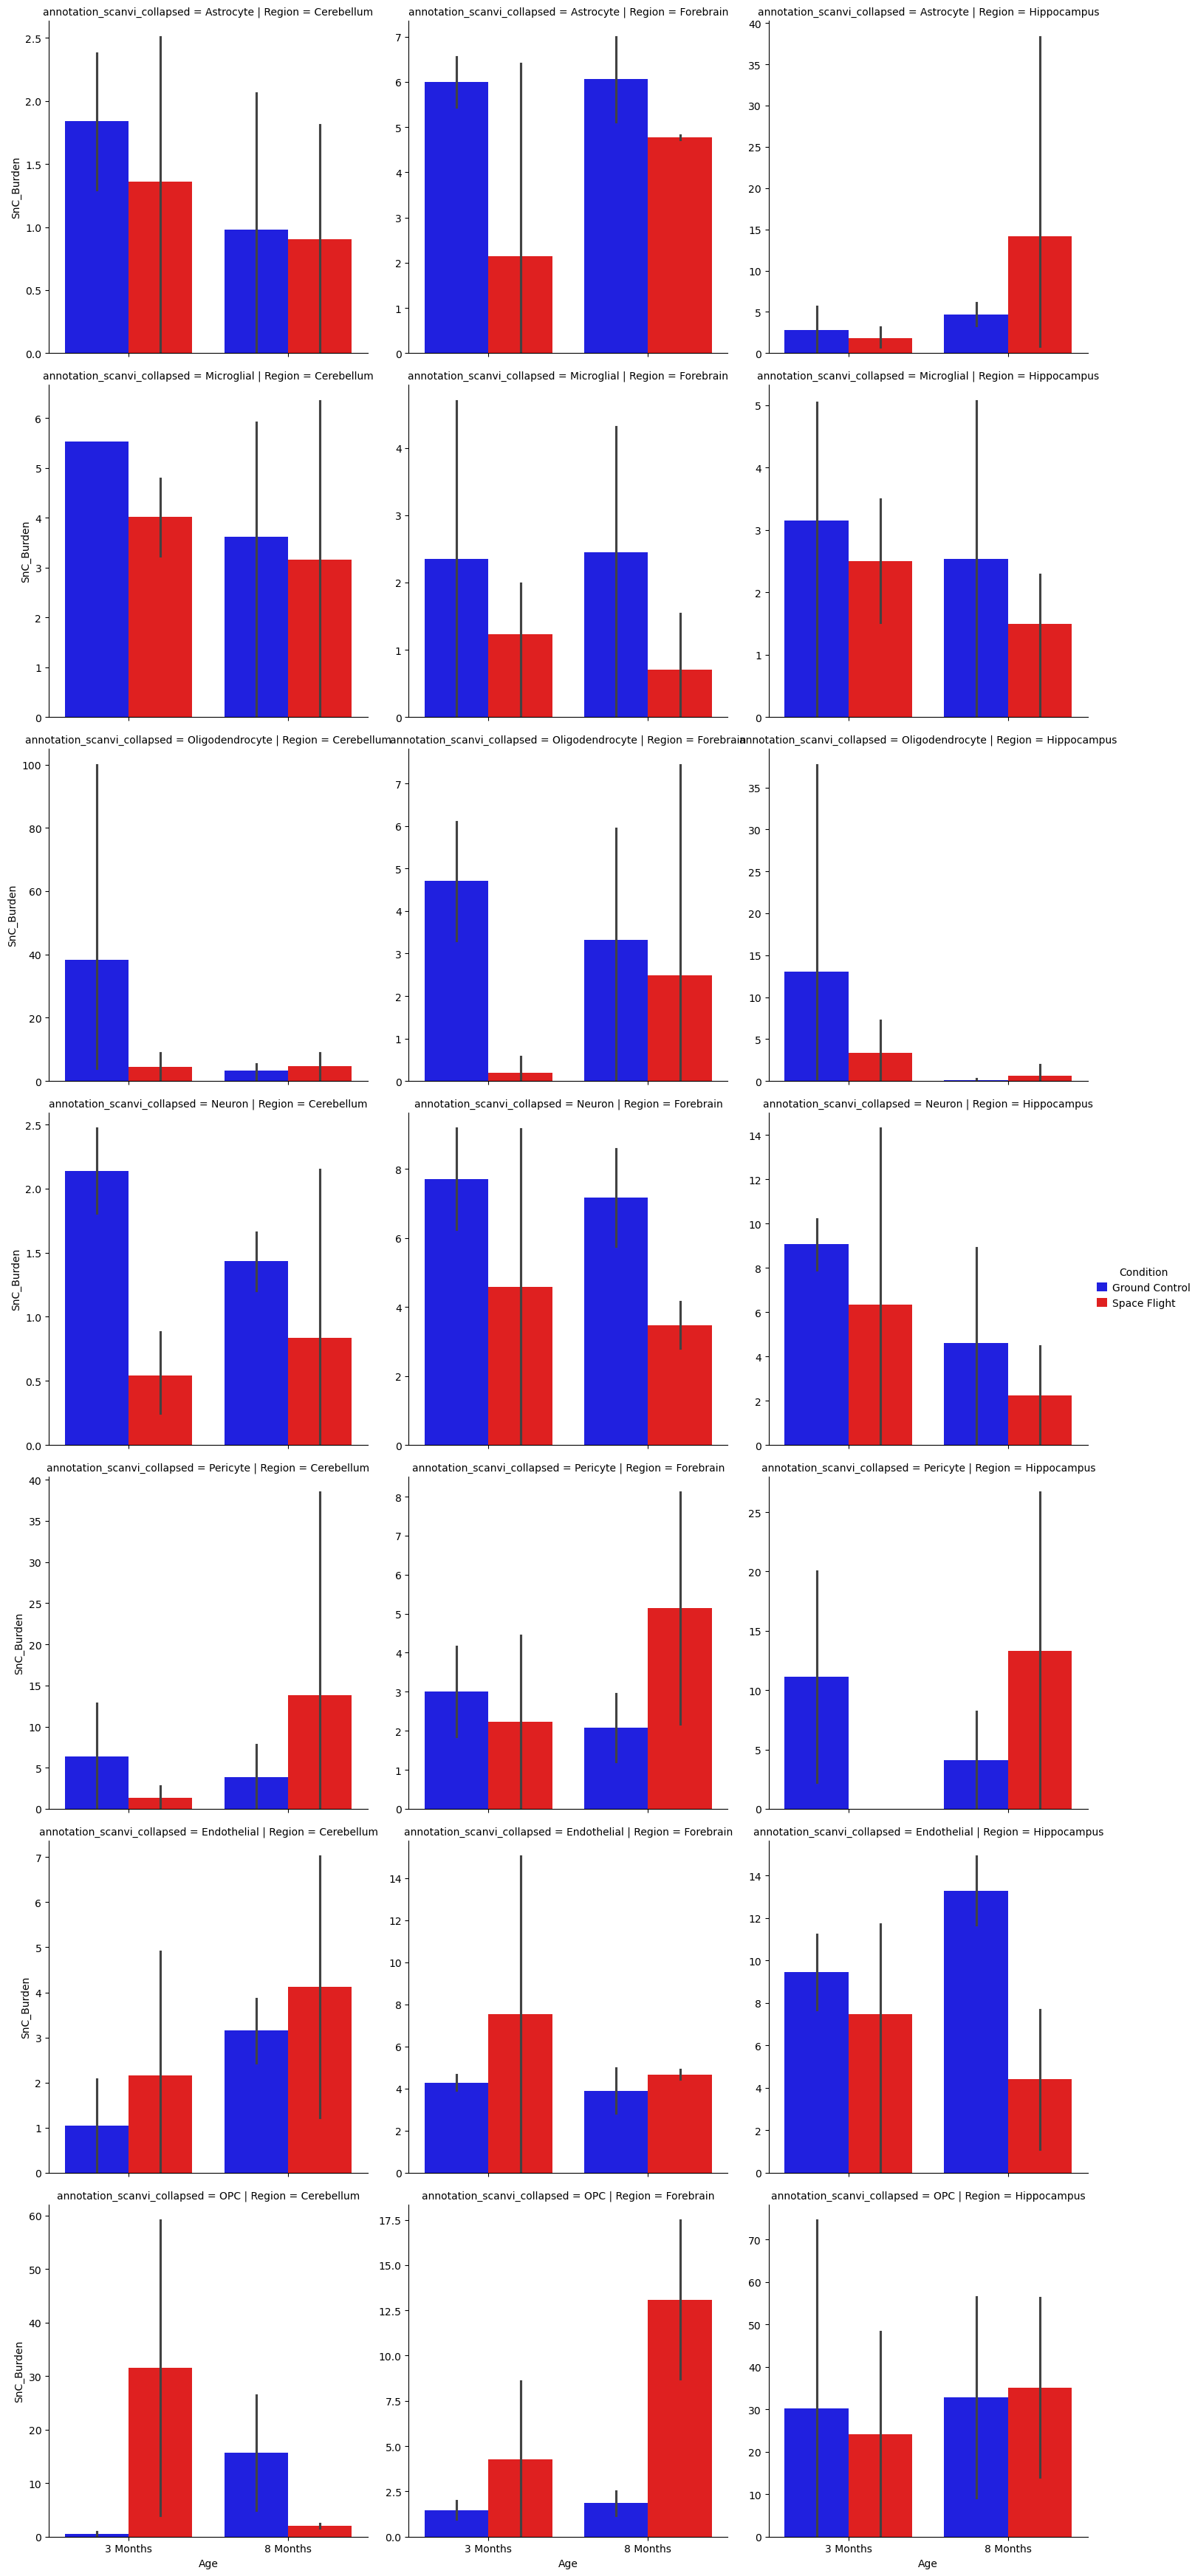

In [4]:
# Control Group Subset Mask Variable (T/F)
senescence_control_subset = (self.rna.obs[col_condition] == keys[
    col_condition]["key_control"]) & (self.rna.obs[col_age] == keys[
        col_age]["key_control"])  # young ground control

# Score Senescence
self.rna.X = self.rna.layers["scaled"].copy()
sc.tl.score_genes(self.rna, mks.loc["Senmayo"],
                  ctrl_as_ref=True, ctrl_size=50, gene_pool=None,
                  n_bins=25, score_name="score_senmayo", random_state=0,
                  copy=False, layer="log1p", use_raw=False)
self.rna.obs["score_senmayo"] = self.rna.obs["score_senmayo"] * scale_factor

# Senescence Score %iles & Threshold(s)
percentile = 100 - percent_snc
if senescence_ct_specific is True:
    if "Senescence_Threshold" in self.rna.obs:
        self.rna.obs = self.rna.obs.drop("Senescence_Threshold", axis=1)
    desc_sen = self.rna[senescence_control_subset].obs.groupby(
        col_celltype).apply(lambda x: np.percentile(
            x["score_senmayo"], percentile), include_groups=False)
    self.rna.obs = self.rna.obs.join(desc_sen.to_frame(
        "Senescence_Threshold"), on=col_celltype).loc[self.rna.obs.index]
else:
    self.rna.obs = self.rna.obs.assign(**{
        "Senescence_Threshold": np.percentile(self.rna[
            senescence_control_subset].obs["score_senmayo"], percentile)})

# Label Senescent Cells
self.rna.obs.loc[:, "Senescent"] = (self.rna.obs[
    "score_senmayo"] > self.rna.obs["Senescence_Threshold"]).astype(float)
self.rna.obs.loc[:, "Senescent_Cell"] = self.rna.obs["Senescent"].map(
    {0: "Non-SnC", 1: "SnC"})
self.rna.obs.loc[:, "Senescent_Cell_by_Type"] = self.rna.obs[
    "Senescent_Cell"] + " " + self.rna.obs[col_celltype].astype(str)
cct = "Senescent_Cell_by_Type"

# SnC Burden by Group, Age, Cell Type
cat_s = [col_sample, col_celltype, col_region, col_age, col_condition]
df_snc_p = self.rna.obs.groupby(cat_s).apply(lambda x: x[
    "Senescent"].mean() * 100, include_groups=False).to_frame("SnC_Burden")
self.rna.obs = self.rna.obs[[i for i in self.rna.obs if i != "SnC_Burden"]]
self.rna.obs = self.rna.obs.join(df_snc_p, on=cat_s).loc[self.rna.obs.index]

# Plots/Results
sns.catplot(df_snc_p, y="SnC_Burden", hue=col_condition,
            x=col_age, sharey=False, col=col_region,
            kind="violin", palette=palette[col_condition])
sns.catplot(df_snc_p, y="SnC_Burden", hue=col_condition,
            x=col_age, sharey=False, col=col_region,
            kind="bar", palette=palette[col_condition])
sns.catplot(df_snc_p, y="SnC_Burden", hue=col_condition, x=col_age,
            col=col_celltype, col_wrap=4, sharey=False,
            kind="bar", palette=palette[col_condition])
fig = sns.catplot(df_snc_p, y="SnC_Burden", hue=col_condition, x=col_celltype,
                  col=col_region, sharey=False,
                  kind="bar", palette=palette[col_condition])
fig.tick_params(rotation=45)
sns.catplot(df_snc_p, y="SnC_Burden", hue=col_condition, x=col_age,
            row=col_celltype, col=col_region, sharey=False,
            kind="bar", palette=palette[col_condition])
print(pd.Series({x: str(len(self.rna[self.rna.obs[cct] == x].obs[
    col_sample].unique())) + " Samples" for x in self.rna.obs[cct].unique()}))
print(round(100 * self.rna.obs[[
    col_condition, col_celltype, "Senescent"]].groupby([
        col_condition, col_celltype]).mean(), 1).unstack(col_condition))
round(100 * self.rna.obs[[
    col_condition, col_age, col_celltype, "Senescent"]].groupby([
        col_condition, col_age, col_celltype]).mean(
            ), 1).unstack(col_condition)

## Make Pseudo-Bulk

### Pseudo-Bulk Function

In [ ]:
def make_pseudobulk(adata, cols_ct, cat_s=None, col_sample=col_sample):
    """Make pseudo-bulk data."""
    # Preserve .obs DataFrame & Translate to Bulked
    obs_original = adata.obs.copy()  # store original obs
    if isinstance(cols_ct, str):
        cols_ct = [cols_ct]
    df_const_samp = adata.obs.groupby(col_sample).apply(lambda x: x.apply(
        lambda y: np.nan if len(y.unique()) > 1 else y.iloc[
            0]), include_groups=False).dropna(axis=1)
    df_const = adata.obs[[i for i in adata.obs if i not in [
        "SnC_Burden", "Senescence_Threshold"] + list(
            df_const_samp.columns)]].groupby(cols_ct).apply(lambda x: x.apply(
                lambda y: y.iloc[0] if len(y.dropna().unique(
                    )) == 1 else np.nan), include_groups=False).dropna(axis=1)
    adata.obs = adata.obs[[col_sample] + cols_ct].copy()

    # Pseudo-Bulk
    pdata = scflow.tl.create_pseudobulk(
        adata, col_sample, cols_ct, layer="counts", mode="sum", method="dc")
    print(pdata.obs, "\n\n\n")
    print(pdata.obs.drop(["psbulk_cells", "psbulk_counts"], axis=1).replace(
        np.nan, "MISSING").value_counts().sort_index(), "\n\n\n")
    adata.obs = obs_original.loc[adata.obs.index].copy()  # restore .obs

    # Restore Full `.obs`
    if not df_const_samp.empty:
        pdata.obs = pdata.obs.rename_axis("ixps").reset_index().set_index(
            col_sample).join(df_const_samp).reset_index().set_index(
                "ixps").loc[pdata.obs.index]
    if not df_const.empty:
        pdata.obs = pdata.obs.rename_axis("ixps").reset_index().set_index(
            df_const.index.names).join(df_const).reset_index().set_index(
                "ixps").loc[pdata.obs.index]

    # Plots
    pdata_subset = pdata.copy()
    pdata_subset.obs = pdata_subset.obs[cat_s].copy()
    dc.tl.rankby_obsm(pdata_subset, key="X_pca")
    dc.pl.obsm(
        pdata_subset, names=[i for i in cat_s if i != col_sample],
        titles=["Principle Component Scores", "Adjusted ANOVA P-Values"],
        figsize=(20, 10), dpi=200)
    del pdata_subset
    sc.pl.pca(pdata, color=[i for i in cat_s if i != col_sample],
              ncols=square_grid(len(cat_s))[1], size=300,
              wspace=0.3, frameon=True)

    # Clean-Up/Display
    dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)
    print(pdata, "\n\n\n")
    return pdata

NameError: name 'dfsad' is not defined

### Make Pseudo-Bulk

Check `.obs` index alignment (should be 1 unique value per combination for column "a"):

```
tmp = np.unique([i for i in [col_sample] + cols_ct + cat_s if i in adata.obs])
tmp = adata.obs[[col_sample] + cols_ct].value_counts().to_frame(
    "a").join(self.rna.obs[tmp].value_counts().to_frame("s")).sort_index()
print(tmp.apply(np.unique))
tmp
```

and 

```
adata.obs[[col_celltype, "Senescent_Cell", cct]].value_counts().sort_index()
```

and  `adata.obs[cols_ct + ["_".join(cols_ct)]].value_counts().sort_index()` or `adata.obs[cols_ct + [col_celltype]].value_counts().sort_index()` or 
```
adata.obs.drop([i for i in adata.obs if i in [
    "psbulk_cells", "psbulk_counts"]], axis=1).value_counts().sort_index()
```

In [ ]:
%%time

# Setup
if ran_psbulk is True:
    raise ValueError("Can't run this cell more than once without resetting")
ran_psbulk = True
adata, pdata = [make_pseudobulk(
    self.rna, cols_ct=x, cat_s=cat_s, col_sample=col_sample)
                for x in [cct, col_celltype]]
for p in [adata, pdata]:
    print(f"\n\n--- {p}\n{p.obs.head(3)} ---\n\n")
    print(p.obs[[i for i in [cct, col_celltype] + ["Senescent_Cell"] if (
        i in p.obs)]].replace(np.nan, "MISSING").value_counts().sort_index())
    print(p.obs[cat_s + list(["Senescent_Cell"] if (
        "Senescent_Cell" in p.obs) else [])].replace(
            np.nan, "MISSING").value_counts().sort_index(), "\n")
# pdata.write_h5ad(
#     f"data/{'_'.join(batches)}__pbulk__{col_celltype}.h5ad")
# adata.write_h5ad(
#     f"data/{'_'.join(batches)}__pbulk__{cct}.h5ad")
pdata_o = pdata.copy()
pdata.obs

### Choose Filtering Parameters

Change `kws_dc_filter_e` and `kws_dc_filter_p` if needed based on QC plot.

In [ ]:
# Filter Samples
min_counts_pb, min_cells_pb = 50, 5
kws_dc_filter_s = dict(
    groupby=groupings,
    min_counts=min_counts_pb, min_cells=min_cells_pb)
for x in [col_region, col_age]:
    print(pdata.obs[(pdata.obs.psbulk_cells > min_cells_pb) & (
        pdata.obs.psbulk_cells > min_counts_pb)][[
            col_condition, col_celltype, x]].value_counts().sort_index())
print(pdata.obs[(pdata.obs.psbulk_cells > min_counts_pb) & (
    pdata.obs.psbulk_cells > min_cells_pb)][[
        col_condition, col_celltype]].value_counts().sort_index())
dc.pl.filter_samples(
    adata=pdata, **kws_dc_filter_s, figsize=(5, 15))
dc.pl.obsbar(adata=pdata, y=col_celltype, hue=col_condition, figsize=(6, 3))
pdata.obs[pdata.obs.psbulk_cells > min_counts_pb][[i for i in kws_dc_filter_s[
    "groupby"] if i != col_subject]].value_counts()

# Filter Genes
kws_dc_filter_e = dict(group=col_condition, min_count=5,
                       min_total_count=15, large_n=4, min_prop=0)
kws_dc_filter_p = dict(min_prop=0, min_smpls=2)
for y, x in zip([col_celltype], [pdata]):
# for y, x in zip([cct, col_celltype], [adata, pdata]):
    fig, axes = plt.subplots(len(x.obs[y].unique()), 2,
                             figsize=(15, 50),
                             gridspec_kw=dict(wspace=0.3, hspace=1))
    for i, q in enumerate(x.obs[y].unique()):
        cells = x[x.obs[y] == q].copy()
        dc.pl.filter_by_expr(adata=cells, **kws_dc_filter_e, ax=axes[i, 0])
        dc.pl.filter_by_prop(adata=cells, **kws_dc_filter_p, ax=axes[i, 1])
        axes[i, 0].set_title(q + " Filtering by Expression")
        axes[i, 1].set_title(q + " Filtering by Proportions")
    fig.suptitle("Candidate Filtering Parameter QC")
    plt.show()
    del cells

# Pseudo-Bulk

## Setup & Filter Samples

In [ ]:
# grps = [i for i in groupings if i not in [col_celltype, col_subject]]
# ct_comp = (100 * self.rna.obs.groupby(grps).value_counts([
#     col_celltype], normalize=True)).to_frame("Composition (%)")
# sns.catplot(ct_comp.reset_index(), x=col_celltype, y="Composition (%)",
#             hue=grps[0], col=grps[1] if len(grps) > 1 else None,
#             row=grps[2] if len(grps) > 2 else None,
#             kind="bar", margin_titles=True,
#             palette=palette[grps[0]] if grps[0] in palette else None)

res_ulm_all = {}  # to hold all results

gpby = kws_dc_filter_s.pop("groupby")
dc.pp.filter_samples(adata=pdata, **{
    i: kws_dc_filter_s[i] for i in kws_dc_filter_s if i != "groupby"})
for x in [i for i in groupings if i not in [col_celltype, col_subject]]:
    dc.pl.obsbar(adata=pdata, y=col_celltype, hue=x, figsize=(6, 3))

## DE + Enrichment/Pathway


### DE

In [ ]:
%%time

# Options
d_x = [col_condition, col_age, col_region]
ctrst = [col_condition, keys[col_condition]["key_treatment"],
         keys[col_condition]["key_control"]]  # contrasting condition labels

# Run PyDESeq
res_deseq, dds, inference, res_ulm = {}, {}, {}, {}
drr = os.path.join(dir_results, "results_pydeseq")
file_deseq = os.path.join(drr, (
    f"results_pydeseq___{'_'.join(batches)}__{col_celltype}__{'_'.join(d_x)}"
    ".xlsx"))  # don't alter "results_pydeseq___" part
files_pkl = {x: os.path.splitext(file_deseq)[0] + f"__{x}.pkl"
             for x in pdata.obs[col_celltype].unique()}
for x in pdata.obs[col_celltype].unique():  # loop cell types
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n")
    try:
        # Filtering Genes
        cells = pdata[pdata.obs[col_celltype] == x].copy()
        dc.pp.filter_by_expr(adata=cells, **kws_dc_filter_e)
        dc.pp.filter_by_prop(adata=cells, **kws_dc_filter_p)
        # Differential Expression
        inference[x] = DefaultInference(n_cpus=ncpus)
        dds[x] = DeseqDataSet(adata=cells, design=f"~{' + '.join(d_x)}",
                              refit_cooks=True, inference=inference[x])
        dds[x].deseq2()
        res_deseq[x] = DeseqStats(
            dds[x], contrast=ctrst, inference=inference[x], n_cpus=ncpus)
        res_deseq[x].summary()
        fig_volc = dc.pl.volcano(res_deseq[x].results_df, x="log2FoldChange",
                                 y="pvalue", return_fig=True, figsize=(8, 6))
        fig_volc.suptitle(f"{x}: {ctrst[1]} vs. {ctrst[2]}")
        # Write Differential Expression Results
        if overwrite is True or os.path.exists(files_pkl[x]) is False:
            print(f">>>Writing results object to {files_pkl[x]}...")
            with open(files_pkl[x], "wb") as f:
                pickle.dump(res_deseq[x], f)
            fff = os.path.join(drr, f"figure_deseq_volcano___" + "___".join(
                os.path.splitext(files_pkl[x])[0].split("___")[1:]) + ".jpg")
            print(f">>>Writing volcano plot to {fff}...")
            fig_volc.savefig(fff, bbox_inches="tight", pad_inches=0.5)
        plt.show()
    except Exception as e:
        print(f"Error processing {x}: {e}\n\n")

# Concatenate Results DataFrame across Cell Types
res_deseq_df = pd.concat({x: res_deseq[x].results_df for x in res_deseq},
                         names=[col_celltype, "Gene"])
res_deseq_de = pd.concat({x: res_deseq[x].design_matrix for x in res_deseq},
                         names=[col_celltype, "Index"])

### Enrichment

#### Function

In [ ]:
def run_enrichment(res_deseq, ctrst, resource, p_adj_threshold=0.05,
                   col_celltype=col_celltype, min_genes=3, figsize=None,
                   plot_trace=True, kws_plot=None, **kwargs):
    """Run enrichment analysis on dictionary of pyDESeq results."""
    res_ulm, figsize = {}, (10, 10) if figsize is None else figsize
    height, aspect = figsize[1], figsize[0] / figsize[1]
    kws_plot = {} if kws_plot is None else {**kws_plot}
    kws_plot = {**dict(palette="vlag", sharey=True, sharex=True, legend=False,
                       height=height, aspect=aspect), **kws_plot}
    # Run Enrichment
    for x in res_deseq:
        print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n")
        res = res_deseq[x].results_df[["stat"]].T.rename(
            index={"stat": f"{ctrst[1]}.vs.{ctrst[2]}"})
        acts, padj = dc.mt.ulm(
            data=res, net=resource, tmin=min_genes, **kwargs)  # run model
        res_ulm[x] = acts.stack().rename_axis([
            "Contrast", "Pathway"]).to_frame("Score").join(padj.stack(
                ).rename_axis([
                    "Contrast", "Pathway"]).to_frame("p_adj"))  # results df
        sig_pth = (padj.T < p_adj_threshold).iloc[:, 0]
        if plot_trace is True:  # trace plots
            for p in sig_pth.replace(False, np.nan).dropna(
                    ).index.values:  # leading edge plot
                fff, l_e = dc.pl.leading_edge(
                    res_deseq[x].results_df, stat="stat", net=resource,
                    name=p, figsize=(10, 6), return_fig=True)
                fff.suptitle(
                    f"{x}\nLeading Edge: {', '.join(l_e[:min(len(l_e), 5)])}")
                fff.tight_layout()
                plt.show()
        if not acts.loc[:, sig_pth].empty:  # enrichment bar plot
            fig_bar = dc.pl.barplot(
                data=acts.loc[:, sig_pth], figsize=figsize,
                name=f"{ctrst[1]}.vs.{ctrst[2]}", return_fig=True)
            fig_bar.suptitle(f"{x}: {ctrst[1]} vs. {ctrst[2]}")
            plt.show()
        else:
            fig_bar = None
            msg = f"Cannot plot bar plot for {x}.\nNo significant pathways."
            print("\n".join([
                f"{'*' * 40}"] * 3) + f"\n\n{msg}\n\n" + "\n".join(
                    [f"{'*' * 40}"] * 3))
    res_ulm_df = pd.concat({x: res_ulm[x] for x in res_ulm},
                           names=[col_celltype, "Contrast", "Pathway"])
    # Plot All
    rrr = res_ulm_df[res_ulm_df["p_adj"] < p_adj_threshold][["Score"]]
    rrr["Score_Absolute"] = rrr["Score"].abs()  # absolute value of score
    rrr = rrr.groupby(col_celltype).apply(lambda x: x.sort_values(
        "Score_Absolute", ascending=False).sort_values(
            "Score", ascending=False), include_groups=False)  # sort
    rrr = rrr.assign(color=rrr["Score"].apply(
        lambda val: "pos" if val >= 0 else "neg")).reset_index(0, drop=True)
    if "col_wrap" not in kws_plot:  # if col_wrap not specified in kws_plot...
        kws_plot["col_wrap"] = square_grid(len(rrr.reset_index()[
            col_celltype].unique()))[1]  # ...square grid ~ # of cell types
    fig = sns.catplot(
        data=rrr, x="Score", y="Pathway", col=col_celltype,
        kind="bar", hue="Score", **kws_plot)  # bar plot
    cmap = matplotlib.colormaps["vlag"]
    lim = max(abs(rrr["Score"].min()), abs(rrr["Score"].max()))
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
    for ax in fig.axes.flatten():
        for bar in ax.patches:
            value = bar.get_width()
            bar.set_facecolor(cmap(norm(value)))
    s_m = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    s_m.set_array([])
    fig.fig.colorbar(s_m, ax=fig.axes, orientation="vertical", label="Score")
    fig.set_titles(col_template="{col_name}")
    return res_ulm, res_ulm_df, rrr, fig

#### Senescence

In [ ]:
# Options
p_adj_threshold = 0.05
lab_path = "senescence"

# Run
res_ulm_all[lab_path.capitalize()] = run_enrichment(
    res_deseq, ctrst, path_snc_df, p_adj_threshold=p_adj_threshold,
    figsize=(5, 5), plot_trace=False)

# Write Plot
fff = os.path.join(dir_results, f"figure_deseq_bar_all___" + "___".join(
    os.path.splitext(file_deseq)[0].split("___")[1:]) + f"__{lab_path}.jpg")
if overwrite is True or os.path.exists(fff) is False:
    print(f"\n\n\n>>>Writing overall barplot to {fff}...")
    res_ulm_all[lab_path.capitalize()][-1].savefig(fff)

#### Custom

In [ ]:
# Options
p_adj_threshold = 0.05
lab_path = "custom"

# Run
res_ulm_all[lab_path.capitalize()] = run_enrichment(
    res_deseq, ctrst, mkdf, p_adj_threshold=p_adj_threshold,
    figsize=(10, 10), plot_trace=False)

# Write Plot
fff = os.path.join(dir_results, f"figure_deseq_bar_all___" + "___".join(
    os.path.splitext(file_deseq)[0].split("___")[1:]) + f"__{lab_path}.jpg")
if overwrite is True or os.path.exists(fff) is False:
    print(f"\n\n\n>>>Writing overall barplot to {fff}...")
    res_ulm_all[lab_path.capitalize()][-1].savefig(fff)

#### Hallmark

In [ ]:
# Options
p_adj_threshold = 0.05
lab_path, resource = "hallmark", dc.op.hallmark(organism=species.lower())

# Run
res_ulm_all[lab_path.capitalize()] = run_enrichment(
    res_deseq, ctrst, resource, p_adj_threshold=p_adj_threshold,
    figsize=(10, 10), plot_trace=False)

# Write Plot
fff = os.path.join(dir_results, f"figure_deseq_bar_all___" + "___".join(
    os.path.splitext(file_deseq)[0].split("___")[1:]) + f"__{lab_path}.jpg")
if overwrite is True or os.path.exists(fff) is False:
    print(f"\n\n\n>>>Writing overall barplot to {fff}...")
    res_ulm_all[lab_path.capitalize()][-1].savefig(fff)

#### Progeny

In [ ]:
# Options
p_adj_threshold = 0.05
lab_path, resource = "progeny", dc.op.progeny(organism=species.lower())

# Run
res_ulm_all[lab_path.capitalize()] = run_enrichment(
    res_deseq, ctrst, resource, p_adj_threshold=p_adj_threshold,
    figsize=(10, 10), plot_trace=False)

# Write Plot
fff = os.path.join(dir_results, f"figure_deseq_bar_all___" + "___".join(
    os.path.splitext(file_deseq)[0].split("___")[1:]) + f"__{lab_path}.jpg")
if overwrite is True or os.path.exists(fff) is False:
    print(f"\n\n\n>>>Writing overall barplot to {fff}...")
    res_ulm_all[lab_path.capitalize()][-1].savefig(fff)

In [ ]:
dc.op.show_resources()

In [9]:
dc.op.resource("KEGG", organism="mouse")

AttributeError: Can only use .str accessor with string values!

In [ ]:
# Options
p_adj_threshold = 0.05
for x in ["KEGG", "GO_Intercell"]:
    resource = dc.op.resource(name=x, organism=species.lower())
    res_ulm_all[x] = run_enrichment(
        res_deseq, ctrst, resource, p_adj_threshold=p_adj_threshold,
        figsize=(10, 10), plot_trace=False)
    fff = os.path.join(dir_results, f"figure_deseq_bar_all___" + "___".join(
        os.path.splitext(file_deseq)[0].split("___")[1:]) + f"__{x}.jpg")
    if overwrite is True or os.path.exists(fff) is False:
        print(f"\n\n\n>>>Writing overall barplot to {fff}...")
        res_ulm_all[x][-1].savefig(fff)

### Write Concatenated Results

In [ ]:
res_ulm_df_all = pd.concat({k: res_ulm_all[k][1] for k in res_ulm_all},
                           names=["Resource"])
if overwrite is True or os.path.exists(file_deseq) is False:
    print(f"\n\n\n>>>Writing results to {file_deseq}...")
    with pd.ExcelWriter(file_deseq, engine="openpyxl") as w:
        res_deseq_df.to_excel(w, sheet_name="Results", index=True)
        res_deseq_de.to_excel(w, sheet_name="Design Matrix", index=True)
        res_ulm_df_all.to_excel(
            w, sheet_name=f"ULM Enrichment All Sets", index=True)
        for p in res_ulm_df_all.reset_index()["Resource"].unique():
            res_ulm_df_all.loc[p].to_excel(
                w, sheet_name=f"ULM Enrichment {p}", index=True)

### Summary All Results

In [ ]:
def color_cells(value):
    """Color cells based on value."""
    if value == "+":
        return "background-color: #f4a3a3;"
    if value == "-":
        return "background-color: #a3c4f4;"
    return ""


res_ulm_df_all_sig = res_ulm_df_all[
    res_ulm_df_all["p_adj"] < 0.01].copy()
if len(res_ulm_df_all_sig.reset_index()["Contrast"].unique()) == 1:
    res_ulm_df_all_sig = res_ulm_df_all_sig.reset_index("Contrast", drop=True)
res_ulm_df_all_sig = res_ulm_df_all_sig["Score"].apply(
    lambda x: "+" if x > 0 else "-" if x < 0 else "NS").unstack(
        "Pathway").replace(np.nan, "")
for x in res_ulm_df_all_sig.reset_index()["Resource"].unique():
    display(res_ulm_df_all_sig.loc[x].replace("", np.nan).dropna(
        how="all", axis=1).replace(np.nan, "").T.style.applymap(color_cells))

## Edgr

In [ ]:
# Options
n_top = 51

# Just Condition
edgr = pt.tl.EdgeR(pdata, design=f"~{col_condition}")
edgr.fit()
res_df_c = edgr.test_contrasts(edgr.contrast(
    column=col_condition, baseline=keys[col_condition]["key_control"],
    group_to_compare=keys[col_condition]["key_treatment"]))
print(res_df_c.head(n_top), "\n\n\n")
edgr.plot_volcano(res_df_c, log2fc_thresh=0)

# Condition x Region
edgr = pt.tl.EdgeR(pdata, design=f"~{col_condition} + {col_region}")
edgr.fit()
res_df = edgr.test_contrasts(edgr.contrast(
    column=col_condition, baseline=keys[col_condition]["key_control"],
    group_to_compare=keys[col_condition]["key_treatment"]))
print(res_df.head(n_top), "\n\n\n")
res_comp = {x: edgr.compare_groups(
    pdata, column=x, baseline=keys[x]["key_control"],
    groups_to_compare=keys[x]["key_treatment"])
            for x in [col_condition, col_region]}
for x in res_comp:
    print(f"{'=' * 80}\n{x}\n{'=' * 80}\n\n{res_comp[x].head(n_top)}")
    edgr.plot_multicomparison_fc(res_comp[x], figsize=(12, 1.5))
edgr.plot_volcano(res_df, log2fc_thresh=0)
edgr.plot_paired(pdata, results_df=res_df, n_top_vars=n_top,
                 groupby=col_condition, pairedby=col_region)

# Condition x Senescence
edgr_snc = pt.tl.EdgeR(adata, design=f"~{col_condition} + Senescent_Cell")
edgr_snc.fit()
res_df_snc = edgr_snc.test_contrasts(edgr_snc.contrast(
    column=col_condition, baseline=keys[col_condition]["key_control"],
    group_to_compare=keys[col_condition]["key_treatment"]))
print(res_df_snc.head(n_top), "\n\n\n")
res_comp_snc = {x: edgr_snc.compare_groups(
    adata, column=x, baseline=keys[x]["key_control"],
    groups_to_compare=keys[x]["key_treatment"])
            for x in [col_condition, "Senescent_Cell"]}
for x in res_comp_snc:
    print(f"{'=' * 80}\n{x}\n{'=' * 80}\n\n{res_comp_snc[x].head(n_top)}")
    edgr_snc.plot_multicomparison_fc(res_comp_snc[x], figsize=(12, 1.5))
edgr_snc.plot_volcano(res_df_snc, log2fc_thresh=0)
edgr_snc.plot_paired(adata, results_df=res_df_snc, n_top_vars=n_top,
                     groupby=col_condition, pairedby="Senescent_Cell")

## Senescence Genes

Igfbp4 (down in spaceflight in all regions, especially in hippocampus) 

Itpka (down in all, especially in hippocampus & forebrain)

Cd9 (down in all, especially in hippocampus)

Bex3 (down hippocampus & forebrain, up in cerebellum)

Mmp13 (up in all)

Ccl24 (down in all)

Mif (down in hippocampus and forebrain)

Hmgb1 (down in hippocampus especially, but also forebrain)

Timp2 (down in hippocampus especially, but also cerebellum)

Cxcr2 (up in cerebellum)

Tnfrsf1a (down in hippocampus and cerebellum)

Ctsb (down in hippocampus, up in forebrain)

In [ ]:
# for x in adata.obs[col_celltype].unique():  # loop cell types
#     print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n")
#     # Enrichment
#     res = res_deseq[x].results_df[["stat"]].T.rename(
#         index={"stat": f"{ctrst[1]}.vs.{ctrst[2]}"})
#     acts, padj = dc.mt.ulm(data=res, net=mkdf)
#     res_ulm_snc[x] = acts.stack().rename_axis([
#         "Contrast", "Pathway"]).to_frame("Score").join(padj.stack(
#             ).rename_axis(["Contrast", "Pathway"]).to_frame(
#                 "p_adj"))  # ULM results df

# # Plot All
# rrr = res_ulm_df[res_ulm_df["p_adj"] < p_adj_threshold][["Score"]]
# rrr["Score_Absolute"] = rrr["Score"].abs()
# rrr = rrr.groupby(ct_loop).apply(lambda x: x.sort_values(
#     "Score_Absolute", ascending=False).sort_values(
#         "Score", ascending=False), include_groups=False)
# rrr = rrr.assign(color=rrr["Score"].apply(
#     lambda val: "pos" if val >= 0 else "neg")).reset_index(0, drop=True)
# fig = sns.catplot(
#     data=rrr, x="Score", y="Pathway", col=ct_loop, kind="bar",
#     hue="Score", palette="vlag", sharey=True, sharex=True, legend=False,
#     col_wrap=square_grid(len(rrr.reset_index()[ct_loop].unique()))[1])
# norm = plt.Normalize(rrr["Score"].min(), rrr["Score"].max())
# s_m = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
# s_m.set_array([])
# fig.fig.colorbar(s_m, ax=fig.axes, orientation="vertical", label="Score")
# fig.set_titles(col_template="{col_name}")

# Single-Cell

## Enrichment

### Setup

In [ ]:
# Group + Cell Type Variable
grp_cell = f"{col_condition}_{col_celltype}"
self.rna.obs.loc[:, grp_cell] = self.rna.obs[col_condition].astype(
    str) + " " + self.rna.obs[col_celltype].astype(str)
sc.tl.rank_genes_groups(self.rna, method="wilcoxon", groupby=grp_cell)

### Blitzgsea

In [ ]:
%%time

# Score Enrichment for Individual Cells
pt_enricher = pt.tl.Enrichment()
pt_enricher.score(self.rna, layer="log1p", targets=mkd)
df_enrich = pd.DataFrame(self.rna.uns["pertpy_enrichment_score"],
                         columns=self.rna.uns["pertpy_enrichment_variables"])

# Check Overrepresentation
sc.tl.rank_genes_groups(self.rna, method="wilcoxon", groupby=grp_cell)
overrepresentation = pt_enricher.hypergeometric(self.rna, targets=mkd)
for x in overrepresentation:
    print(f"\n\n{'=' * 80}\nOverrepresentation: Hypergeometric Test Results "
          f"({x})\n{'=' * 80}\n{overrepresentation[x]}")

# Blitzgsea
enrichment = pt_enricher.gsea(self.rna, targets=mkd)
pt_enricher.plot_gsea(self.rna, enrichment, interactive_plot=True)
res_gsea = {**self.rna.uns["pertpy_enrichment_gsea"]}
for g in mkd:
    for c in res_gsea["scores"]:
        fig = blitz.plot.running_sum(
            signature=res_gsea["scores"][c], geneset=g,
            library=res_gsea["targets"], result=enrichment[c],
            interactive_plot=True)
        fig.show()
        fig.suptitle(c)

### GSEApy

#### Overall

In [ ]:
resource = "GO_Biological_Process_2021"
t_x = keys[col_condition]["key_treatment"]
sc.tl.rank_genes_groups(
    self.rna, groupby=col_condition, use_raw=False,  method="wilcoxon",
    groups=[keys[col_condition]["key_treatment"]],
    reference=keys[col_condition]["key_control"],
    key_added=f"rank_genes_groups_{col_condition}")
sc.pl.rank_genes_groups(self.rna, n_genes=25, sharey=False,
                        key=f"rank_genes_groups_{col_condition}")
result = self.rna.uns[f"rank_genes_groups_{col_condition}"]
groups = result["names"].dtype.names
degs = pd.DataFrame({group + "_" + key: result[key][
    group] for group in groups for key in [
        "names","scores", "pvals","pvals_adj","logfoldchanges"]})
print(degs.head())
pre_res = gp.prerank(degs.loc[:, [
    f"{t_x}_names", f"{t_x}_logfoldchanges"]], gene_sets="KEGG_2016")
print(pre_res.res2d.head(25))
term2 = pre_res.res2d.Term
axes = pre_res.plot(terms=term2[:int(min([25, len(term2)]))])
degs_sig = degs[degs[f"{t_x}_pvals_adj"] < 0.05]
degs_up = degs_sig[degs_sig[f"{t_x}_logfoldchanges"] > 0]
degs_dw = degs_sig[degs_sig[f"{t_x}_logfoldchanges"] < 0]
enr_up = gp.enrichr(degs_up[f"{t_x}_names"], gene_sets=resource, outdir=None)
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(10, 12), title="Up",
           cmap=plt.cm.autumn_r, top_term=25)
enr_dw = gp.enrichr(degs_dw[f"{t_x}_names"], gene_sets=resource, outdir=None)
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d, figsize=(10, 12), title="Down",
           cmap=plt.cm.winter_r, size=5, top_term=25)
results_enrichr_overall = [pre_res, degs, enr_up, enr_dw]

#### By Cell Type

In [ ]:
results_enrichr = {}
for x in self.rna.obs[col_celltype].unique():
    print(f"{'=' * 80}\n{x}\n{'=' * 80}\n\n")
    bdata = self.rna[self.rna.obs[col_celltype] == x].copy()
    t_x = keys[col_condition]["key_treatment"]
    sc.tl.rank_genes_groups(
        bdata, groupby=col_condition, use_raw=False,  method="wilcoxon",
        groups=[keys[col_condition]["key_treatment"]],
        reference=keys[col_condition]["key_control"],
        key_added=f"rank_genes_groups_{col_condition}")
    sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False,
                            key=f"rank_genes_groups_{col_condition}")
    result = bdata.uns[f"rank_genes_groups_{col_condition}"]
    groups = result["names"].dtype.names
    degs = pd.DataFrame({group + "_" + key: result[key][
        group] for group in groups for key in [
            "names","scores", "pvals","pvals_adj","logfoldchanges"]})
    print(degs.head())
    pre_res = gp.prerank(degs.loc[:, [
        f"{t_x}_names", f"{t_x}_logfoldchanges"]], gene_sets="KEGG_2016")
    print(pre_res.res2d.head(25))
    term2 = pre_res.res2d.Term
    axes = pre_res.plot(terms=term2[:int(min([25, len(term2)]))])
    degs_sig = degs[degs[f"{t_x}_pvals_adj"] < 0.05]
    degs_up = degs_sig[degs_sig[f"{t_x}_logfoldchanges"] > 0]
    degs_dw = degs_sig[degs_sig[f"{t_x}_logfoldchanges"] < 0]
    enr_up = gp.enrichr(degs_up[f"{t_x}_names"],
                        gene_sets="GO_Biological_Process_2021", outdir=None)
    enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
    try:
        gp.dotplot(enr_up.res2d, figsize=(10, 12), title=f"Up ({x})",
                   cmap=plt.cm.autumn_r, top_term=20)
    except Exception as err:
        print(f"Plotting up failed for {x}: {err}")
    enr_dw = gp.enrichr(degs_dw[f"{t_x}_names"],
                        gene_sets="GO_Biological_Process_2021", outdir=None)
    enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
    try:
        gp.dotplot(enr_dw.res2d, figsize=(10, 12), title=f"Down ({x})",
                   cmap=plt.cm.winter_r, size=5, top_term=20)
    except Exception as err:
        print(f"Plotting up failed for {x}: {err}")
    results_enrichr[x] = [pre_res, degs, enr_up, enr_dw]

## Pathway Analysis

In [ ]:
res_gsea = {}
for x in self.rna.obs[col_celltype].unique():
    print(f"{'=' * 80}\n{x}\n{'=' * 80}\n\n")
    bdata = self.rna[self.rna.obs[col_celltype] == x].copy()
    res_gsea[x] = gp.gsea(
        data=bdata.to_df().T,
        gene_sets="GO_Biological_Process_2021", cls=bdata.obs[col_condition],
        permutation_num=1000, permutation_type="phenotype", outdir=None,
        method="s2n", threads=ncpus)
    axs = res_gsea[x].plot(terms=res_gsea[x].res2d.Term)
    for i in np.arange(len(res_gsea[x].res2d.Lead_genes)):
        genes = res_gsea[x].res2d.Lead_genes.iloc[i].split(";")
        ax2 = gp.heatmap(
            df=res_gsea[x].heatmat.loc[genes], z_score=None,
            title=res_gsea[x].res2d.Term.iloc[i], figsize=(6,5),
            cmap=plt.cm.viridis, xticklabels=False)

## Cell-Cell Interaction

Create Environment for R Script:

```
conda env create -f sce_env.yml
conda activate sce_env
conda install -c conda-forge anndata scanpy -y
R
```

In R (choose "a" or "1" to update all whenever prompted):

```
setRepositories(ind = 1:3, addURLs = c("https://satijalab.r-universe.dev", "https://bnprks.r-universe.dev/"))
remotes::install_github("satijalab/seurat-data", quiet = TRUE)
remotes::install_github("satijalab/azimuth", quiet = TRUE)
remotes::install_github("satijalab/seurat-wrappers", quiet = TRUE)
install.packages("BiocManager")
BiocManager::install(c("LoomExperiment", "SingleCellExperiment"))
devtools::install_github("cellgeni/sceasy")
install.packages("Signac", dependencies = TRUE)
install.packages("reticulate")
```

Then in Bash: `export RETICULATE_PYTHON=$(conda run -n sce_env which python)`

In [ ]:
# %load_ext rpy2.ipython

# # Ignore R warning messages
# #Note: this can be commented out to get more verbose R output
# # rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# cpdb_version = "v5.0.0"
# cpdb_target_dir = os.path.join("scratch", cpdb_version)
# db_utils.download_database(cpdb_target_dir, cpdb_version)
# db_utils.create_db(cpdb_target_dir)

# anndata2ri.set_ipython_converter()

# ####################################

# %%R -i self.rna
# self.rna

# ####################################

# %%R -o degs_cpdb

# library(Seurat)

# s_o = as.Seurat(self.rna, counts="X", data="X")
# Idents(s_o) = s_o$cell_type
# degs_cpdb <- FindAllMarkers(
#     s_o, test.use = "LR", verbose = F, only.pos = T, random.seed = 1,
#     logfc.threshold = 0.2, min.pct = 0.1, return.thresh = 0.05)
# degs_cpdb.to_csv(file_degs_seurat, index=False, sep="\t")
# degs_cpdb = degs_cpdb[[all(tup) for tup in zip(
#     degs_cpdb["p_val_adj"] < 0.05, degs_cpdb["avg_log2FC"] > 0.1)]]
# degs_cpdb = degs_cpdb[["cluster", "gene", "p_val_adj", "p_val",
#                        "avg_log2FC", "pct.1", "pct.2"]]
# degs_cpdb.to_csv(file_degs_seurat, index=False, sep="\t")

# Set File Paths & Write Data
dir_work = "scratch/cellphonedb"
os.makedirs(dir_work, exist_ok=True)
frs = os.path.join(dir_work, "run_seurat.R")
file_data = os.path.join(dir_work, "rna.h5ad")
file_rds = os.path.join(dir_work, "rna.rds")
file_degs = os.path.join(dir_work, "DEGs.tsv")
file_meta_cpbd = os.path.join(dir_work, "metadata.tsv")
self.rna.obs.loc[:, "cell_type"] = self.rna.obs[col_celltype].copy()
pd.DataFrame(data={"Cell":list(self.rna.obs.index), "cell_type": [
    i for i in self.rna.obs["cell_type"]]}).set_index("Cell").to_csv(
        file_meta_cpbd, sep = "\t")
self.rna.write(file_data)  # save AnnData -> RDS

# Write R Script
r_script = textwrap.dedent(f"""
    suppressPackageStartupMessages({{
        library(Seurat)
        library(sceasy)z
        library(reticulate)
    }})
    use_python(file.path(Sys.getenv("CONDA_PREFIX"), "bin/python"),
               required = TRUE)
    py_config()
    sceasy::convertFormat("{file_data}", from="anndata", to="seurat",
                          outFile="{file_rds}")
    s_o <- LoadH5Seurat("{file_rds}")
    Idents(s_o) <- s_o$cell_type
    degs <- FindAllMarkers(
        s_o, test.use = "LR", verbose = FALSE,
        only.pos = TRUE, random.seed = 1,
        logfc.threshold = 0.2, min.pct = 0.1, return.thresh = 0.05
    )
    degs <- degs[degs$p_val_adj < 0.05 & degs$avg_log2FC > 0.1, ]
    write.table(
        degs, file = "{file_degs}", sep = "\\t",
        row.names = FALSE, quote = FALSE
    )
""")
with open(frs, "w") as file_conn:
    file_conn.write(r_script)

# To Conserve Memory
del self

# Run DEG Analysis (R Script)
print("\n\n\n\n\n>>>Running R Script...")
subprocess.run(["conda", "run", "-n", "sce_env", "Rscript", frs], check=True)

# Reload Object
print("\n\n\n\n\n>>>Reloading object...")
self = scflow.Rna(file_data, col_sample=col_sample,
                  col_subject=col_subject, col_batch=col_batch,
                  col_celltype=col_celltype, integrated=True)






>>>Running R Script...


In [ ]:
subprocess.run(["conda", "run", "-n", "sce_env", "Rscript", frs], check=True)












In [ ]:
# Download CellPhoneDB Database
cpdb_version = "v5.0.0"
cpdb_target_dir = os.path.join("scratch", cpdb_version)
db_utils.download_database(cpdb_target_dir, cpdb_version)
db_utils.create_db(cpdb_target_dir)

# Run Analysis
cpdb_results = cpdb_degs_analysis_method.call(
         cpdb_file_path=os.path.join(cpdb_target_dir, "cellphonedb.zip"),
         meta_file_path=file_meta_cpbd,
         counts_file_path=file_path,
         degs_file_path=file_degs_seurat,
         counts_data="hgnc_symbol",
         threshold=0.1, output_path=dir_cpdb)
file_degs_seurat_final, file_meta_cpbd_final = [os.path.join(os.path.join(
    dir_results, "cellphonedb", x)) for x in ["DEGs.tsv", "metadata.tsv"]]

# Write Results
for x in [file_degs_seurat_final, file_meta_cpbd_final]:
    os.makedirs(x, exist_ok=True)

# Regressions

## Setup

In [ ]:
r_dff = polars.DataFrame(df_snc_p.reset_index())  # pymer aggregated
r_rna = polars.DataFrame(self.rna.obs.rename({
    col_celltype: "CT_"}, axis=1).copy())  # pymer-compatible cell-level df
lvls = ["key_control", "key_treatment"]
factors = {col_condition: [keys[col_condition][i] for i in lvls],
           col_age: [keys[col_condition][i] for i in lvls]}

## Cell Type & Region as Random Effect Units

In [ ]:
# Condition
model_ca_mlm_i = lmer(
    f"score_senmayo ~ {col_condition}"
    f" + (1 | {col_subject})"
    f" + (1 + {col_condition} || CT_)"
    f" + (1 + {col_condition} || {col_region})",
    data=r_rna)  # set up model
model_ca_mlm_i.set_factors({col_condition: factors[col_condition]})
model_ca_mlm_i.set_transforms({"score_senmayo": "zscore"})
model_ca_mlm_i.anova(summary=True).show()

# Region + Condition
model_ca_mlm_ii = lmer(
    f"score_senmayo ~ {col_condition} + {col_age_binary}"
    f" + (1 | {col_subject})"
    f" + (1 + {col_condition} + {col_age_binary} | CT_)"
    f" + (1 + {col_condition} + {col_age_binary} | {col_region})",
    data=r_rna)  # set up model
# model_ca_mlm_ii.set_factors(factors)
model_ca_mlm_ii.set_transforms({"score_senmayo": "zscore"})
model_ca_mlm_ii.anova(summary=True).show()

# Region * Condition
model_ca_mlm_iii = lmer(
    f"score_senmayo ~ {col_condition} * {col_age_binary}"
    f" + (1 | {col_subject})"
    f" + (1 + {col_condition} + {col_age_binary} | CT_)"
    f" + (1 + {col_condition} + {col_age_binary} | {col_region})",
    data=r_rna)  # set up model
# model_ca_mlm_iii.set_factors(factors)
model_ca_mlm_iii.set_transforms({"score_senmayo": "zscore"})
model_ca_mlm_iii.anova(summary=True).show()

# Model Comparison
compare(model_ca_mlm_i, model_ca_mlm_ii, model_ca_mlm_iii).show()

# GLM Version of Results
model_ca_mlm_i.summary().show()
model_ca_mlm_ii.summary().show()
model_ca_mlm_iii.summary().show()

## Binary SnC

In [ ]:
glmmod = {}
for x in ["1", f"1 + {col_condition_binary}",
            f"1 + {col_condition_binary} + {col_age_binary}",
            f"1 + {col_condition_binary} * {col_age_binary}"]:
    sep = "|" if x == "1" else "||"
    fff = str(f"Senescent ~ {col_condition_binary if x == '1' else x}"
              f" + (1 | {col_subject})"
              f" + ({x} {sep} CT_)"
              f" + ({x} {sep} {col_region})")
    glmmod[x] = glmer(fff, data=r_rna, family="binomial")
    glmmod[x].fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
    glmmod[x].summary().show()
    # print(glmmod[x].ranef["CT_"])
# compare(*[glmmod[x] for x in glmmod])
fff = str(f"Senescent ~ {col_condition_binary} * CT_"
            f" + (1 | {col_subject})"
            f" + ({x} {sep} {col_region})")
glmmod["ix"] = glmer(fff, data=r_rna, family="binomial")
glmmod["ix"].fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod["ix"].summary().show()

# Write Outputs

In [ ]:
if overwrite is True or not os.path.exists(html_out):
    os.system(f"jupyter nbconvert --to html {cur_file} --output {html_out}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")